# LIGO NF-PE Calibration Pipeline

**DSC 207 (UC Berkeley) course project.** Trains a normalizing-flow neural
posterior estimator (`sbi` SNPE + MAF) on simulated binary-black-hole (BBH)
signals injected into real LIGO H1 noise from the O3a observing run, then
tests whether its calibration holds up when evaluated on O4a noise instead
-- a real, documented hardware/sensitivity upgrade the model never trained
on. Calibration is assessed via Simulation-Based Calibration (SBC).

see `PROPOSAL.md` for full scope and `BACKGROUND.md`/`TUTORIAL.md`
if any of the above is unfamiliar.

**Pipeline stages** (each independently resumable via a validated on-disk
checkpoint -- `ligo_pipeline.utils.save_checkpoint`/`load_checkpoint`):

```
raw strain (S3) ──▶ EDA / whitening sanity checks
GWOSC noise segments (O3a, O4a) ──▶ PSD estimation ──▶ cheap PSD-drift check
BBH injections (waveform + noise + SNR gate) ──▶ preprocessing (whiten/bandpass/crop)
train/test split ──▶ SNPE (MAF) training ──▶ posterior checkpoint
SBC on O3a (baseline) and O4a (cross-run test) ──▶ calibration comparison
```

Reused helpers (noise acquisition, injection generation, preprocessing,
checkpointing, evaluation) live in `ligo_pipeline/` and are imported below;
every tunable parameter lives in `config.py`. Everything else -- the actual
calls, loops, plots, and the narrative explaining what each result means --
is in this notebook, in order, so it can be read top to bottom.

All artifacts are written under `../artifacts/` (gitignored).


### How to read the next cell

This first code cell only prepares the workspace. It imports the scientific libraries and the project's reusable pipeline functions so the notebook can speak in terms of strain, noise, injections, posterior samples, and calibration. Nothing is being trained yet, and no scientific conclusion is made here. Think of it as laying out the instruments on the bench before the experiment starts.

In [1]:
import sys
from pathlib import Path

# so `import config` / `import ligo_pipeline` resolve to the project root
# regardless of whether Jupyter's cwd is DSC207/ or DSC207/notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import io
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.signal import spectrogram

import boto3
from botocore.exceptions import BotoCoreError, ClientError, NoCredentialsError

from sbi.inference import SNPE
from sbi.utils import BoxUniform

import config
from ligo_pipeline.utils import (
    setup_logging, save_checkpoint, load_checkpoint, retry,
    validate_finite, validate_strain, validate_psd, validate_sample_rate,
)
from ligo_pipeline.noise import (
    lookup_event_gps, validate_noise_segments, acquire_noise_segments, average_psd,
)
from ligo_pipeline.preprocessing import (
    estimate_psd, whiten, bandpass, whiten_and_bandpass,
    compute_derived_params, preprocess_injection, validate_training_data,
)
from ligo_pipeline.injections import (
    WaveformGenerationError, draw_bbh_params, generate_injection,
    generate_injection_dataset, validate_injection_dataset,
)
from ligo_pipeline.evaluation import (
    validate_sbc_ranks, summarize_sbc_ks, run_sbc_with_retries, clean_sbc_ranks,
    repeated_subsample_ks, detect_psd_drift,
)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/alilordifar/opt/anaconda3/envs/ligo-poc/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/alilordifar/opt/anaconda3/envs/ligo-poc/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/Users/alilordifar/opt/anaconda3/envs/ligo-poc/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/alilordifar/opt/anaconda3/envs/ligo-poc/lib/python3.11/site-pa

## Setup: logging, artifact layout, configuration

Logging, checkpointing, and validation are all defined once in
`ligo_pipeline/utils.py` (imported above) and configured here. Two log
handlers: a concise `INFO`-level stream to this notebook's output, and a
verbose `DEBUG`-level file under `artifacts/logs/` for post-mortem
debugging. Per-item detail inside loops of hundreds of iterations is logged
at `DEBUG` and summarized at `INFO` so the notebook output stays readable.

Every parameter that affects a scientific result lives in `config.CONFIG`
(see `config.py`) -- nothing below should hardcode a value that also
appears there, so the logged record of "what ran" can never drift from what
actually ran.


### What this setup records

This cell creates the artifact folders, fixes random seeds, starts logging, and records the exact configuration and software versions. That matters because this is an experiment: later, a reader should be able to tell which detector, frequency band, SNR threshold, sample counts, and model settings produced a result.

In [2]:
for _path in config.ARTIFACT_DIRS.values():
    _path.mkdir(parents=True, exist_ok=True)

logger = setup_logging(config.ARTIFACT_DIRS["logs"])

CONFIG = config.CONFIG
config.set_global_seeds(CONFIG["global_seed"])
CONFIG["software_versions"] = config.get_software_versions()

logger.info("Config loaded. detector=%s train_run=%s eval_run=%s sample_rate=%dHz "
            "bandpass=%g-%gHz snr_threshold=%.1f approximant=%s n_injections/run=%d "
            "model=%s+%s global_seed=%d",
            CONFIG["detector"], CONFIG["train_run"], CONFIG["eval_run"],
            CONFIG["sample_rate_hz"], CONFIG["bandpass_low_hz"], CONFIG["bandpass_high_hz"],
            CONFIG["snr_threshold"], CONFIG["waveform_approximant"], CONFIG["n_injections_per_run"],
            CONFIG["model_family"], CONFIG["density_estimator"], CONFIG["global_seed"])
logger.debug("Full config: %s", json.dumps(CONFIG, default=str, indent=2))


20:06:05 INFO    Logging initialized. Console=INFO, full debug log=/Users/alilordifar/Library/CloudStorage/GoogleDrive-ali.lordifar@gmail.com/My Drive/Projects/gravitational-wave-ml-pipeline/DSC207/artifacts/logs/pipeline_20260912T000605Z.log


/Users/alilordifar/opt/anaconda3/envs/ligo-poc/lib/python3.11/importlib/__init__.py:126: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


20:06:06 INFO    Config loaded. detector=H1 train_run=O3a eval_run=O4a sample_rate=4096Hz bandpass=35-350Hz snr_threshold=8.0 approximant=IMRPhenomD n_injections/run=800 model=SNPE+MAF global_seed=1234


## Section 1 -- Raw ingested strain: exploratory sanity checks

Before touching GWOSC directly, sanity-check one already-ingested H1
segment from the platform's own bronze S3 layer, and confirm
whitening/bandpassing (via `ligo_pipeline.preprocessing`) recovers a
plausible chirp around a real cataloged event. Read-only against S3; the
only thing written is an optional `.wav` audio preview.


### Why begin with a real event?

Before generating artificial examples, we check that the raw H1 data behaves like real detector data and that the signal-processing tools can reveal a known merger. This is a reality check for the pipeline, not training data for the neural network.

### Connecting to the data store

The next cell creates a small S3 reader with bounded retries. It does not analyze the signal yet; it only establishes a reliable way to fetch the metadata and strain array. If this step fails, the problem is access or networking, not gravitational-wave modeling.

### Confirming what is stored

This cell lists the objects under the expected S3 prefix. The useful question is simple: are the files that the configuration names actually present? Listing first makes a missing-file or wrong-path problem visible before the notebook tries to interpret bytes as science.

### Reading the segment's identity card

The JSON file describes the array: its sampling rate, duration, GPS start time, and expected number of samples. Treat this like checking a specimen label before measuring it. The following code prints that label so later plots can be put on the correct time axis.

### Loading the actual strain

Now the metadata is paired with the time-series array: one detector measurement per sample. The validation checks are intentionally boring but essential. A missing sample, NaN, or wrong length could create a beautiful-looking but physically meaningless plot.

### Turning samples into real time

A detector array is indexed by sample number, but gravitational-wave events are discussed in seconds and GPS time. This small conversion creates the time coordinate used by every event-centered plot that follows.

### Looking at the raw detector trace

This plot shows the detector's full strain segment. Most of what you see is noise, because LIGO is measuring incredibly small disturbances continuously. At this stage, do not expect an obvious chirp; the point is to see the raw scale and confirm the time series is present.

### Optional: making the signal audible

This cell rescales the strain and writes a WAV preview. It is only an intuition aid: the audio is not the physical sound of the merger and it is not used by the model. The scientific data remains the original numerical strain array.

### Finding the event in GPS time

The catalog gives the merger's GPS timestamp. This lookup turns the human-readable event name into the exact coordinate needed to zoom into the correct samples instead of guessing where the signal is.

### Zooming around the merger

The full trace hides the event inside thousands of seconds of mostly noise. This zoom asks the tangible question: when we look just around the known merger time, is there a localized feature for the signal-processing pipeline to work with?

### A quick local-noise sanity check

A real event should not make the entire nearby window look wildly unlike ordinary detector noise. Comparing the standard deviation near the event with a quiet reference window helps catch indexing or corrupted-data mistakes before any filtering is trusted.

### Estimating the detector's noise fingerprint

The PSD describes how noisy each frequency is. Whitening will divide out this frequency-dependent noise, so a frequency where the detector is naturally loud does not dominate simply because of the instrument. This is the first real signal-processing step used later for every injection.

### What whitening should change

This plot uses the same event-centered window after whitening. Compare it with the raw plot: the purpose is not to make the event larger by magic, but to put frequencies on a more comparable noise scale so the chirp can be inspected fairly.

### Seeing the chirp in time and frequency

The spectrogram is the most intuitive view of a merger: time runs horizontally and frequency vertically. A BBH chirp rises toward higher frequency and brightens near merger. The bandpass removes regions where this detector is less useful, making the pattern easier to see.

In [3]:
@retry(times=3, exceptions=(BotoCoreError, ClientError, ConnectionError))
def s3_list_objects(client, bucket, prefix):
    resp = client.list_objects_v2(Bucket=bucket, Prefix=prefix)
    return resp.get("Contents", [])


@retry(times=3, exceptions=(BotoCoreError, ClientError, ConnectionError))
def s3_get_bytes(client, bucket, key):
    obj = client.get_object(Bucket=bucket, Key=key)
    return obj["Body"].read()


try:
    s3 = boto3.client("s3", region_name=CONFIG["s3_region"])
except (BotoCoreError, NoCredentialsError) as exc:
    logger.error("Failed to create S3 client: %s", exc)
    raise


In [4]:
logger.info("Listing ingested H1 objects under %s", CONFIG["eda_prefix"])
try:
    eda_objects = s3_list_objects(s3, CONFIG["s3_bucket"], CONFIG["eda_prefix"])
except (BotoCoreError, ClientError) as exc:
    logger.error("Failed to list S3 objects at %s: %s", CONFIG["eda_prefix"], exc)
    raise

for obj in eda_objects:
    print(obj["Key"])
logger.info("Found %d object(s) under %s.", len(eda_objects), CONFIG["eda_prefix"])


20:06:12 INFO    Listing ingested H1 objects under raw/domain=ligo/source_id=H1/year=2023/month=09/day=02/
raw/domain=ligo/source_id=H1/year=2023/month=09/day=02/H1_1693666670.000_4096.000.json
raw/domain=ligo/source_id=H1/year=2023/month=09/day=02/H1_1693666670.000_4096.000.npy
20:06:13 INFO    Found 2 object(s) under raw/domain=ligo/source_id=H1/year=2023/month=09/day=02/.


In [5]:
try:
    meta_bytes = s3_get_bytes(s3, CONFIG["s3_bucket"], CONFIG["eda_json_key"])
    meta = json.loads(meta_bytes)
except (BotoCoreError, ClientError) as exc:
    logger.error("Failed to fetch metadata object %s: %s", CONFIG["eda_json_key"], exc)
    raise
except json.JSONDecodeError as exc:
    logger.error("Metadata object %s is not valid JSON: %s", CONFIG["eda_json_key"], exc)
    raise

logger.info("Loaded metadata for %s (sample_rate=%d Hz, duration=%d s).",
            CONFIG["eda_json_key"], meta["sample_rate_hz"], meta["duration_sec"])
print(json.dumps(meta, indent=2))


20:06:16 INFO    Loaded metadata for raw/domain=ligo/source_id=H1/year=2023/month=09/day=02/H1_1693666670.000_4096.000.json (sample_rate=4096 Hz, duration=4096 s).
{
  "domain": "ligo",
  "source_id": "H1",
  "start_time_utc": 1693666670.0,
  "sample_rate_hz": 4096,
  "duration_sec": 4096,
  "num_samples": 16777216,
  "extra": {
    "gps_start": 1377701888,
    "gps_end": 1377705984
  }
}


In [6]:
try:
    npy_bytes = s3_get_bytes(s3, CONFIG["s3_bucket"], CONFIG["eda_npy_key"])
    data = np.load(io.BytesIO(npy_bytes))
except (BotoCoreError, ClientError) as exc:
    logger.error("Failed to fetch strain array %s: %s", CONFIG["eda_npy_key"], exc)
    raise

validate_strain(data, "raw H1 strain (EDA segment)")
logger.info("Loaded %d s of H1 strain at %d Hz (shape=%s, dtype=%s).",
            meta["duration_sec"], meta["sample_rate_hz"], data.shape, data.dtype)
print(data.shape, data.dtype)
print(data.min(), data.max(), data.mean(), data.std())

# sanity check against metadata -- fail fast rather than silently analyzing a
# truncated or mislabeled array
expected_samples = meta["sample_rate_hz"] * meta["duration_sec"]
if not (data.shape[0] == expected_samples == meta["num_samples"]):
    raise ValueError(
        f"Sample count mismatch for {CONFIG['eda_npy_key']}: array has "
        f"{data.shape[0]} samples, metadata implies sample_rate*duration="
        f"{expected_samples} and num_samples={meta['num_samples']}."
    )


20:06:24 INFO    Loaded 4096 s of H1 strain at 4096 Hz (shape=(16777216,), dtype=float64).
(16777216,) float64
-6.354604304027749e-18 6.3049566561072805e-18 1.0953377396205081e-23 1.1024815600430135e-18


In [7]:
# time calculation
sample_rate = meta["sample_rate_hz"]
t0 = meta["extra"]["gps_start"]
dt = 1.0 / sample_rate

times = t0 + np.arange(data.shape[0]) * dt
print(times[0], times[-1], times[-1] - times[0])


1377701888.0 1377705983.9997559 4095.999755859375


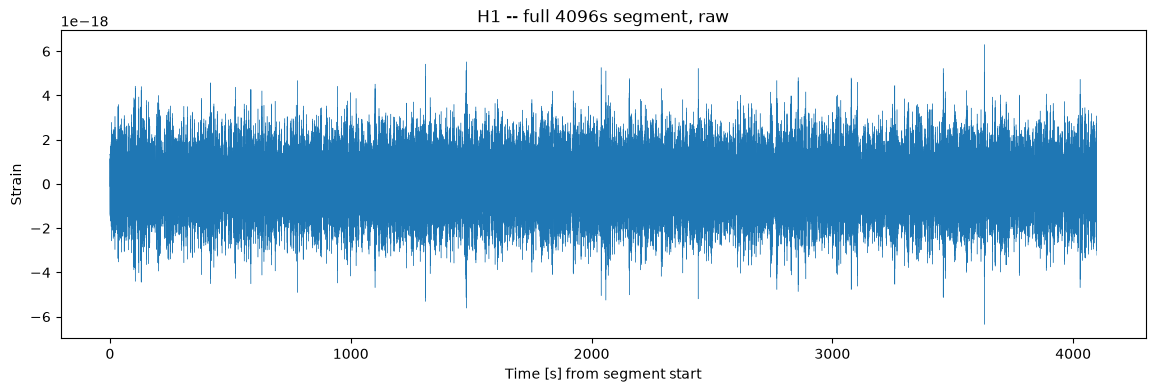

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(times - t0, data, linewidth=0.3)
ax.set_xlabel("Time [s] from segment start")
ax.set_ylabel("Strain")
ax.set_title("H1 -- full 4096s segment, raw")
plt.show()


In [9]:
# normalize to [-1, 1] range for an audio preview
#### IT IS NOT AN IMPORTANT CELL
import os
from scipy.io import wavfile

wav_path = config.ARTIFACT_DIRS["audio"] / "h1_segment.wav"

if wav_path.exists():
    logger.warning("Audio preview already exists at %s -- skipping regeneration "
                   "(deterministic function of the source strain, safe to reuse).", wav_path)
else:
    try:
        audio = data / np.max(np.abs(data))
        validate_finite(audio, "audio_preview")
        tmp_wav = wav_path.with_name(wav_path.name + ".tmp")
        wavfile.write(tmp_wav, sample_rate, audio.astype(np.float32))
        os.replace(tmp_wav, wav_path)  # atomic: never leaves a half-written .wav
        logger.info("Saved audio preview to %s", wav_path)
    except (OSError, ValueError) as exc:
        logger.error("Failed to write audio preview %s: %s", wav_path, exc)
        raise


20:06:44 INFO    Saved audio preview to /Users/alilordifar/Library/CloudStorage/GoogleDrive-ali.lordifar@gmail.com/My Drive/Projects/gravitational-wave-ml-pipeline/DSC207/artifacts/audio/h1_segment.wav


In [10]:
try:
    event_gps_time = lookup_event_gps(CONFIG["eda_event_name"])
except Exception as exc:
    logger.error("Failed to resolve GPS time for event %s: %s", CONFIG["eda_event_name"], exc)
    raise

logger.info("%s merger GPS time: %.3f", CONFIG["eda_event_name"], event_gps_time)
print(event_gps_time)


20:06:56 INFO    GW230902_150325 merger GPS time: 1377702223.200
1377702223.2


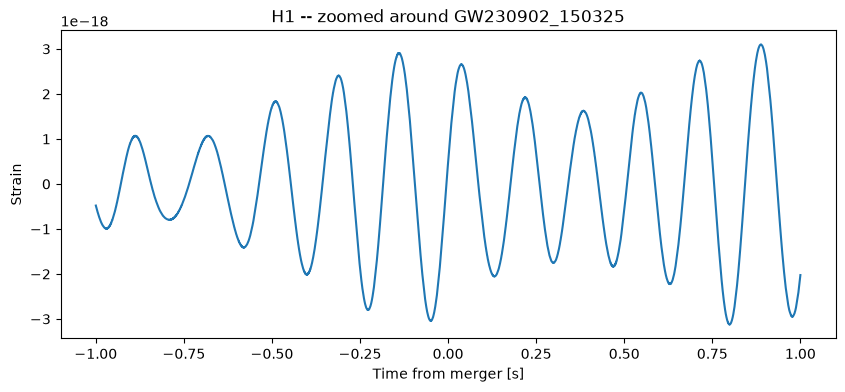

In [11]:
window = 1.0  # seconds either side of merger
mask = (times >= event_gps_time - window) & (times <= event_gps_time + window)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times[mask] - event_gps_time, data[mask])
ax.set_xlabel("Time from merger [s]")
ax.set_ylabel("Strain")
ax.set_title(f"H1 -- zoomed around {CONFIG['eda_event_name']}")
plt.show()


In [12]:
# quick reality check: near-merger variance should look the same order of
# magnitude as a quiet reference window -- a huge discrepancy would indicate
# a data/indexing bug rather than a real signal, before we go further
far_mask = (times >= times[0] + 100) & (times <= times[0] + 102)
std_near, std_far = np.std(data[mask]), np.std(data[far_mask])
logger.debug("std near merger window=%.3e, std of quiet reference window=%.3e", std_near, std_far)
print("std near merger:", std_near, " | std of quiet reference window:", std_far)


std near merger: 1.5674633742829548e-18  | std of quiet reference window: 1.4111478746521577e-18


In [13]:
logger.info("Estimating PSD and whitening the full %d s segment...", meta["duration_sec"])
freqs, psd = estimate_psd(data, sample_rate)
whitened = whiten(data, sample_rate, freqs, psd)
logger.info("Whitening complete.")


20:07:30 INFO    Estimating PSD and whitening the full 4096 s segment...
20:07:31 INFO    Whitening complete.


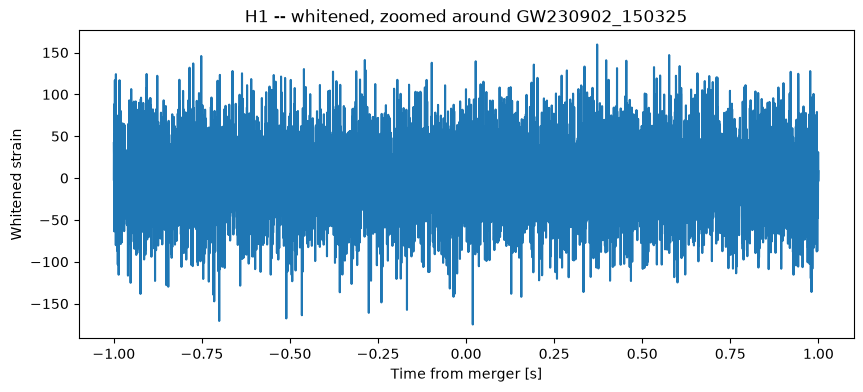

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times[mask] - event_gps_time, whitened[mask])
ax.set_xlabel("Time from merger [s]")
ax.set_ylabel("Whitened strain")
ax.set_title(f"H1 -- whitened, zoomed around {CONFIG['eda_event_name']}")
plt.show()


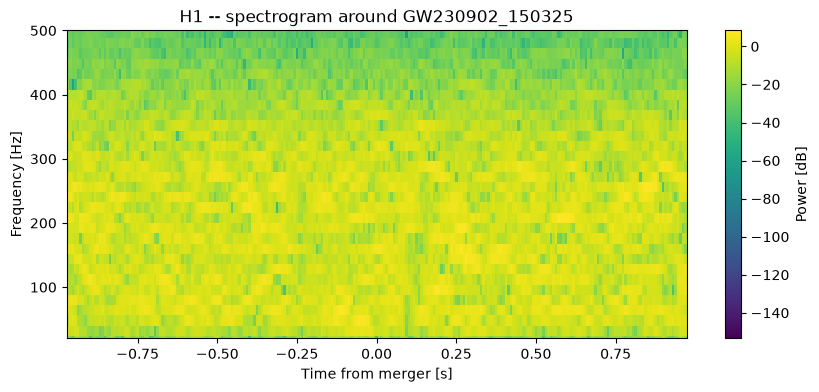

In [15]:
bandpassed = bandpass(whitened, sample_rate)

f, t_spec, Sxx = spectrogram(bandpassed[mask], fs=sample_rate, nperseg=256, noverlap=224)

fig, ax = plt.subplots(figsize=(10, 4))
mesh = ax.pcolormesh(t_spec - window, f, 10 * np.log10(Sxx), shading="auto")
ax.set_ylim(20, 500)
ax.set_xlabel("Time from merger [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title(f"H1 -- spectrogram around {CONFIG['eda_event_name']}")
plt.colorbar(mesh, ax=ax, label="Power [dB]")
plt.show()


### Comparison: GW150914 (the original 2015 detection)

Same whitening/bandpass pipeline, applied to the ingested GW150914 segment,
as a second sanity check with tighter time resolution (GW150914's chirp is
much faster than GW230902's).


### Why compare a second real event?

GW150914 is a familiar reference case with a much faster chirp. Repeating the same whitening and spectrogram idea on it checks that the pipeline is not tuned accidentally to one event's duration or visual shape.

### Loading the comparison event

This cell repeats the same careful procedure for GW150914: fetch metadata and strain, validate the array, and locate the merger. Repetition here is intentional; a reusable scientific pipeline should behave consistently across known events.

### Plotting the faster chirp

Here the same signal-processing recipe produces a tighter event-centered spectrogram. The expected visual difference is useful: waveform duration changes with the source masses, while the physical idea of an upward-sweeping chirp remains the same.

### Measuring excess power rather than raw brightness

This final diagnostic normalizes each frequency by its usual power and asks where the event is unusually strong. That makes the plot easier to interpret across frequencies: bright means “more powerful than normal for this frequency,” not simply “a frequency that is always loud.”

### Repeating the data check for GW150914

The next cell only lists the comparison event's stored objects. It is the same access check as before, now aimed at the original detection so the notebook can compare two real, known signals using one processing recipe.

### Loading and locating GW150914

This cell fetches the comparison event, validates its strain, builds its GPS time axis, and resolves the catalog merger time. Its output should establish the exact window that the following plot will inspect.

### Visualizing GW150914 after preprocessing

This cell applies the same PSD estimation, whitening, bandpass, and event-centered spectrogram to GW150914. The tighter 0.3-second window is chosen because this heavier system sweeps through the sensitive band quickly.

### Making the comparison plot easier to read

The following view divides each frequency row by its own median power. It emphasizes the merger's excess over the local background and helps a reader recognize the chirp even when the raw detector spectrum is dominated by its usual frequency-dependent shape.

In [16]:
logger.info("Listing ingested H1 objects under %s", CONFIG["gw150914_prefix"])
try:
    gw150914_objects = s3_list_objects(s3, CONFIG["s3_bucket"], CONFIG["gw150914_prefix"])
except (BotoCoreError, ClientError) as exc:
    logger.error("Failed to list S3 objects at %s: %s", CONFIG["gw150914_prefix"], exc)
    raise

for obj in gw150914_objects:
    print(obj["Key"])
logger.info("Found %d object(s) under %s.", len(gw150914_objects), CONFIG["gw150914_prefix"])


20:08:06 INFO    Listing ingested H1 objects under raw/domain=ligo/source_id=H1/year=2015/
raw/domain=ligo/source_id=H1/year=2015/month=09/day=14/H1_1442224245.000_4096.000.json
raw/domain=ligo/source_id=H1/year=2015/month=09/day=14/H1_1442224245.000_4096.000.npy
raw/domain=ligo/source_id=H1/year=2015/month=10/day=12/H1_1444643183.000_4096.000.json
raw/domain=ligo/source_id=H1/year=2015/month=10/day=12/H1_1444643183.000_4096.000.npy
raw/domain=ligo/source_id=H1/year=2015/month=12/day=26/H1_1451099085.000_4096.000.json
raw/domain=ligo/source_id=H1/year=2015/month=12/day=26/H1_1451099085.000_4096.000.npy
20:08:06 INFO    Found 6 object(s) under raw/domain=ligo/source_id=H1/year=2015/.


In [17]:
try:
    meta_bytes = s3_get_bytes(s3, CONFIG["s3_bucket"], CONFIG["gw150914_json_key"])
    meta_gw150914 = json.loads(meta_bytes)
    npy_bytes = s3_get_bytes(s3, CONFIG["s3_bucket"], CONFIG["gw150914_npy_key"])
    data_gw150914 = np.load(io.BytesIO(npy_bytes))
except (BotoCoreError, ClientError) as exc:
    logger.error("Failed to fetch GW150914 segment (%s / %s): %s",
                 CONFIG["gw150914_json_key"], CONFIG["gw150914_npy_key"], exc)
    raise
except json.JSONDecodeError as exc:
    logger.error("GW150914 metadata is not valid JSON: %s", exc)
    raise

validate_strain(data_gw150914, "GW150914 H1 strain")
sample_rate_gw150914 = meta_gw150914["sample_rate_hz"]
t0_gw150914 = meta_gw150914["extra"]["gps_start"]
times_gw150914 = t0_gw150914 + np.arange(data_gw150914.shape[0]) / sample_rate_gw150914

try:
    event_gps_gw150914 = lookup_event_gps("GW150914")
except Exception as exc:
    logger.error("Failed to resolve GPS time for GW150914: %s", exc)
    raise

logger.info("Loaded GW150914 segment: %d s at %d Hz, merger GPS=%.3f",
            meta_gw150914["duration_sec"], sample_rate_gw150914, event_gps_gw150914)
print(meta_gw150914)
print(event_gps_gw150914, times_gw150914[0], times_gw150914[-1])


20:08:09 INFO    Loaded GW150914 segment: 4096 s at 4096 Hz, merger GPS=1126259462.400
{'domain': 'ligo', 'source_id': 'H1', 'start_time_utc': 1442224245.0, 'sample_rate_hz': 4096, 'duration_sec': 4096, 'num_samples': 16777216, 'extra': {'gps_start': 1126259462, 'gps_end': 1126263558}}
1126259462.4 1126259462.0 1126263557.9997559


### Inspecting the GW150914 input itself

After locating the event, this cell loads the actual metadata and strain array. The printed GPS bounds and sample rate are the evidence that the following spectrogram will be centered on the intended event rather than on a guessed or shifted index.

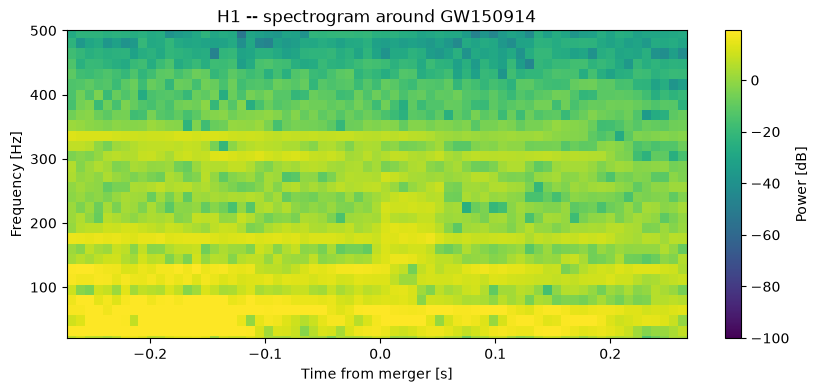

In [18]:
freqs_gw150914, psd_gw150914 = estimate_psd(data_gw150914, sample_rate_gw150914)
bandpassed_gw150914 = whiten_and_bandpass(data_gw150914, sample_rate_gw150914, freqs_gw150914, psd_gw150914)

gw150914_window = 0.3  # GW150914's chirp is fast; tighter window than GW230902
mask_gw150914 = (times_gw150914 >= event_gps_gw150914 - gw150914_window) & \
                (times_gw150914 <= event_gps_gw150914 + gw150914_window)

f, t_spec, Sxx = spectrogram(bandpassed_gw150914[mask_gw150914], fs=sample_rate_gw150914,
                              nperseg=256, noverlap=224)

fig, ax = plt.subplots(figsize=(10, 4))
db = 10 * np.log10(Sxx)
mesh = ax.pcolormesh(t_spec - gw150914_window, f, db, shading="auto",
                      vmin=np.percentile(db, 5), vmax=np.percentile(db, 99))
ax.set_ylim(20, 500)
ax.set_xlabel("Time from merger [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("H1 -- spectrogram around GW150914")
plt.colorbar(mesh, ax=ax, label="Power [dB]")
plt.show()


### Reading the GW150914 spectrogram

This plot is the visual signal check: after whitening and bandpassing, the merger should appear as a compact rising-frequency track. The axes tell you when the track occurs and which frequencies carry the visible evidence.

### Isolating the event's excess above background

The last diagnostic rescales each frequency by its typical power and shows only the event's excess. This is a display transformation, not a new dataset or a new model input; it exists to make the astrophysical track visually legible.

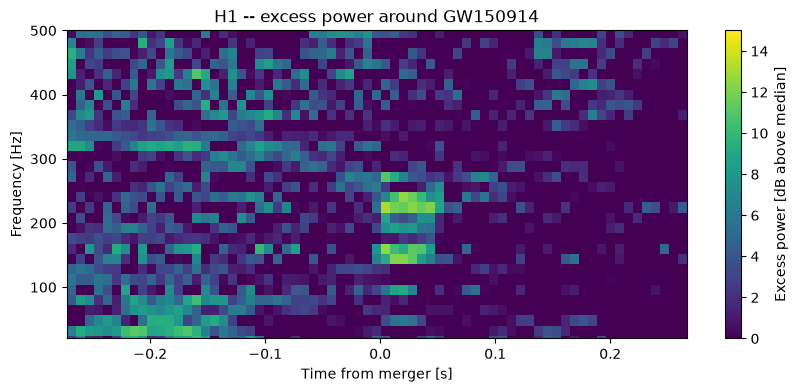

In [19]:
# normalize each frequency row by its own median power across time
# -> "how many times louder than usual is this frequency, right now"
median_per_freq = np.median(Sxx, axis=1, keepdims=True)
excess_power = Sxx / median_per_freq

fig, ax = plt.subplots(figsize=(10, 4))
mesh = ax.pcolormesh(t_spec - gw150914_window, f, 10 * np.log10(excess_power), shading="auto",
                      vmin=0, vmax=15)
ax.set_ylim(20, 500)
ax.set_xlabel("Time from merger [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("H1 -- excess power around GW150914")
plt.colorbar(mesh, ax=ax, label="Excess power [dB above median]")
plt.show()


## Section 2 -- GWOSC noise segment acquisition (O3a, O4a)

For each observing run we need `n_noise_segments_per_run` quality-vetted,
event-free noise segments (`ligo_pipeline.noise.acquire_noise_segments`).
This is the most expensive network-bound stage in the notebook (each
candidate segment is a multi-hundred-MB GWOSC frame download), so it is
fully checkpointed: if a compatible `o{run}_noise_segments.pkl` already
exists under `artifacts/data/noise/`, **the GWOSC event catalog query and
all frame downloads are skipped entirely**.

`fetch_clean_noise` (inside `acquire_noise_segments`) distinguishes an
**expected scientific rejection** (implausible noise std, failing the DQ
bitmask, spanning multiple frame files, NaNs -- logged at `DEBUG`, loop just
moves on) from an **unexpected failure** (malformed HDF5, wrong sample rate
-- logged at `ERROR`/raised, since that means something is actually broken).
Network failures get 3 bounded retries with backoff before a candidate is
skipped.


### Building the O3a noise background

The model must learn from signals buried in realistic detector noise, not clean textbook waveforms. This cell searches O3a for long, event-free, quality-vetted H1 segments and caches them. A rejected segment is not a failed experiment; it is a segment that should not be used as a trustworthy background.

### Checking the accepted O3a segments

This summary lets us inspect the actual backgrounds selected for training: their size, standard deviation, and NaN status. The important interpretation is that every segment passed the basic integrity gates before it can receive a simulated signal.

### Building the O4a evaluation background

O4a is collected with the same quality rules but from a different observing run. This is the crucial separation: the model will train on O3a backgrounds, then face signals embedded in O4a backgrounds it never saw during training.

### Comparing the two noise fingerprints

The ASD curve is the detector's noise floor as a function of frequency. A gap between O3a and O4a means the model's input environment changed before we even ask whether its posterior uncertainty changed. This plot motivates the cheap drift check in the next cells.

### Acquiring the first run's noise

The next code block either loads O3a noise from its validated checkpoint or downloads and vets new segments. The scientific object produced here is a dictionary of clean 1024-second arrays, ready to receive injections.

### Inspecting the O3a noise records

This small output is a human-readable audit of the cached object. The shape confirms each segment has the expected 1024 × 4096 samples; the standard deviation and NaN flag provide a quick check that the accepted backgrounds are finite and plausible.

### Acquiring the second run's noise

O4a goes through the same acquisition and validation path. Keeping the code path parallel is important: otherwise an apparent calibration difference could come from different data-cleaning rules rather than the observing run itself.

### Building the run-to-run comparison

Now the two collections of real noise are reduced to average ASD curves. The output is a compact summary of the input distributions the model will encounter: where O4a is louder, quieter, or shaped differently from O3a across frequency.

In [20]:
o3a_noise_path = config.ARTIFACT_DIRS["noise"] / "o3a_noise_segments.pkl"
o3a_noise_meta = {
    "run": CONFIG["train_run"],
    "detector": CONFIG["detector"],
    "segment_duration_sec": CONFIG["noise_segment_duration_sec"],
    "n_segments": CONFIG["n_noise_segments_per_run"],
    "sample_rate_hz": CONFIG["sample_rate_hz"],
    "std_range": list(CONFIG["noise_std_range"]),
    "dq_cbc_bits": list(CONFIG["dq_cbc_bits"]),
    "event_exclusion_buffer_sec": CONFIG["event_exclusion_buffer_sec"],
    "seed": CONFIG["random_seed_o3a_noise"],
}

from gwosc import datasets as gwosc_datasets

logger.info("Starting %s noise segment acquisition.", CONFIG["train_run"])
noise_segments, _status = load_checkpoint(
    o3a_noise_path, expected_meta=o3a_noise_meta,
    validator=lambda obj: validate_noise_segments(obj, CONFIG["noise_segment_duration_sec"], CONFIG["sample_rate_hz"]),
)
if noise_segments is None:
    start_o3a, end_o3a = gwosc_datasets.run_segment(CONFIG["train_run"])
    noise_segments = acquire_noise_segments(
        CONFIG["train_run"], start_o3a, end_o3a, CONFIG["n_noise_segments_per_run"],
        CONFIG["noise_segment_duration_sec"], CONFIG["event_exclusion_buffer_sec"],
        CONFIG["random_seed_o3a_noise"],
    )
    save_checkpoint(o3a_noise_path, noise_segments, o3a_noise_meta)
logger.info("%s noise segment acquisition complete.", CONFIG["train_run"])


20:08:16 INFO    Starting O3a noise segment acquisition.
20:08:16 INFO    Querying GWOSC event catalog for O3a (GPS 1238166018-1253977218)...
20:08:40 INFO    O3a: 63 cataloged events, resolved 63 GPS times (0 lookups failed).
20:08:40 INFO    O3a: 118/120 candidate windows are event-free (buffer=3600s).
20:12:05 INFO    O3a: accepted noise segment start=1238298877, std=3.419e-19 (1/8).
20:12:39 INFO    O3a: accepted noise segment start=1239893180, std=3.434e-19 (2/8).
20:21:07 INFO    O3a: accepted noise segment start=1249060425, std=1.626e-19 (3/8).
20:21:36 INFO    O3a: accepted noise segment start=1239627463, std=3.429e-19 (4/8).
20:22:20 INFO    O3a: accepted noise segment start=1239228887, std=3.434e-19 (5/8).
20:22:48 INFO    O3a: accepted noise segment start=1239361746, std=3.446e-19 (6/8).
20:23:05 INFO    O3a: accepted noise segment start=1241088908, std=1.001e-19 (7/8).
20:27:30 INFO    O3a: accepted noise segment start=1238431735, std=3.416e-19 (8/8).
20:27:30 INFO    O3a n

### Auditing O3a noise before injection

The acquisition cell has produced candidate backgrounds; this output is the quick numerical audit. The values should show consistent shapes, finite samples, and plausible standard deviations across the selected O3a segments.

In [21]:
for t0, (seg, seg_times) in noise_segments.items():
    print(f"{t0:.0f}: std={seg.std():.3e}, shape={seg.shape}, has_nan={np.any(np.isnan(seg))}")


1238298877: std=3.419e-19, shape=(4194304,), has_nan=False
1239893180: std=3.434e-19, shape=(4194304,), has_nan=False
1249060425: std=1.626e-19, shape=(4194304,), has_nan=False
1239627463: std=3.429e-19, shape=(4194304,), has_nan=False
1239228887: std=3.434e-19, shape=(4194304,), has_nan=False
1239361746: std=3.446e-19, shape=(4194304,), has_nan=False
1241088908: std=1.001e-19, shape=(4194304,), has_nan=False
1238431735: std=3.416e-19, shape=(4194304,), has_nan=False


In [22]:
o4a_noise_path = config.ARTIFACT_DIRS["noise"] / "o4a_noise_segments.pkl"
o4a_noise_meta = {
    "run": CONFIG["eval_run"],
    "detector": CONFIG["detector"],
    "segment_duration_sec": CONFIG["noise_segment_duration_sec"],
    "n_segments": CONFIG["n_noise_segments_per_run"],
    "sample_rate_hz": CONFIG["sample_rate_hz"],
    "std_range": list(CONFIG["noise_std_range"]),
    "dq_cbc_bits": list(CONFIG["dq_cbc_bits"]),
    "event_exclusion_buffer_sec": CONFIG["event_exclusion_buffer_sec"],
    "seed": CONFIG["random_seed_o3a_noise"],  # same acquisition seed policy; run differs via run_segment bounds
}

logger.info("Starting %s noise segment acquisition.", CONFIG["eval_run"])
noise_segments_o4a, _status = load_checkpoint(
    o4a_noise_path, expected_meta=o4a_noise_meta,
    validator=lambda obj: validate_noise_segments(obj, CONFIG["noise_segment_duration_sec"], CONFIG["sample_rate_hz"]),
)
if noise_segments_o4a is None:
    start_o4a, end_o4a = gwosc_datasets.run_segment(CONFIG["eval_run"])
    noise_segments_o4a = acquire_noise_segments(
        CONFIG["eval_run"], start_o4a, end_o4a, CONFIG["n_noise_segments_per_run"],
        CONFIG["noise_segment_duration_sec"], CONFIG["event_exclusion_buffer_sec"],
        CONFIG["random_seed_o3a_noise"],
    )
    save_checkpoint(o4a_noise_path, noise_segments_o4a, o4a_noise_meta)
logger.info("%s noise segment acquisition complete.", CONFIG["eval_run"])


21:26:12 INFO    Starting O4a noise segment acquisition.
21:26:13 INFO    Querying GWOSC event catalog for O4a (GPS 1368195220-1389456018)...
21:27:08 INFO    O4a: 140 cataloged events, resolved 140 GPS times (0 lookups failed).
21:27:08 INFO    O4a: 115/120 candidate windows are event-free (buffer=3600s).
21:27:49 INFO    O4a: accepted noise segment start=1384274041, std=1.084e-18 (1/8).
21:28:15 INFO    O4a: accepted noise segment start=1386775191, std=1.089e-18 (2/8).
21:29:17 INFO    O4a: accepted noise segment start=1386239230, std=1.122e-18 (3/8).
21:29:40 INFO    O4a: accepted noise segment start=1373197520, std=1.377e-18 (4/8).
21:30:04 INFO    O4a: accepted noise segment start=1374984055, std=1.135e-18 (5/8).
21:30:31 INFO    O4a: accepted noise segment start=1385703269, std=1.632e-18 (6/8).
21:30:43 INFO    O4a: accepted noise segment start=1374448095, std=1.215e-18 (7/8).
21:31:04 INFO    O4a: accepted noise segment start=1370339063, std=1.446e-18 (8/8).
21:31:04 INFO    O4a

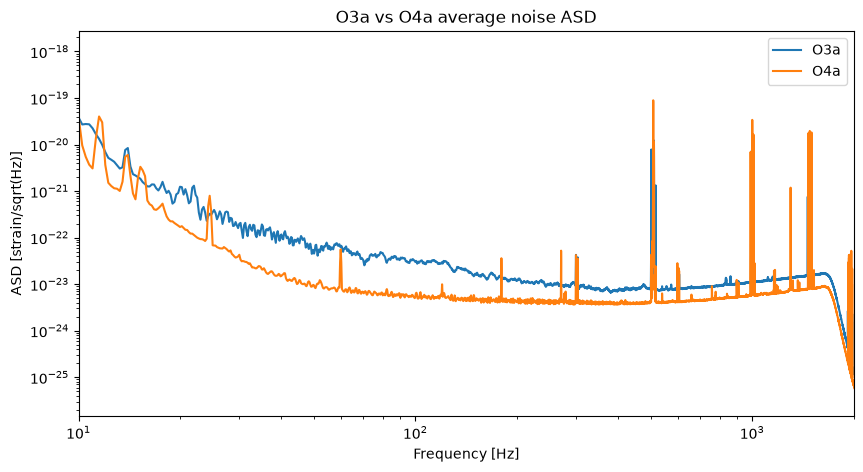

In [23]:
freqs_o3a, psd_o3a = average_psd(noise_segments, CONFIG["sample_rate_hz"])
freqs_o4a, psd_o4a = average_psd(noise_segments_o4a, CONFIG["sample_rate_hz"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(freqs_o3a, np.sqrt(psd_o3a), label=CONFIG["train_run"])
ax.loglog(freqs_o4a, np.sqrt(psd_o4a), label=CONFIG["eval_run"])
ax.set_xlim(10, 2000)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [strain/sqrt(Hz)]")
ax.legend()
ax.set_title(f"{CONFIG['train_run']} vs {CONFIG['eval_run']} average noise ASD")
plt.show()


### Cheap monitoring signal: would a PSD-drift check have flagged this before SBC ever ran?

SBC (Section 7) is the expensive, ground-truth way to check calibration --
but it requires a trained model and hundreds of posterior-sampling calls.
Before ever running it, could a much cheaper signal -- comparing the two
runs' average noise curves above, which we've already computed -- have
flagged "this pair of runs looks different enough that retraining/re-
evaluation is warranted"?

This is a monitoring-signal demonstration, not a full drift-detection
pipeline: two complementary, easily-computed criteria
(`ligo_pipeline.evaluation.detect_psd_drift`), both operating only on the
in-band (`bandpass_low_hz`-`bandpass_high_hz`) average ASD curves already
plotted above --

1. a two-sample KS-test comparing the shape of the two in-band ASD curves,
2. the median relative ASD difference in-band, thresholded.

No new data acquisition, no new model training -- just reusing
`average_psd`'s output. See `TUTORIAL.md` for why a KS-test is a reasonable
tool here and `PROPOSAL.md` for the important caveat that the thresholds
below are illustrative defaults, not validated/tuned ones.


### Turning the PSD comparison into a monitoring decision

The next cell compresses the two ASD curves into two readable signals: a shape-difference score and a typical relative amplitude difference. This is not the final calibration test. It is an inexpensive early warning: “should we spend the time to run the full posterior check?”

### Reading the drift flag

The printed result gives four pieces of information: the KS statistic, its illustrative p-value, the median ASD difference, and the combined Boolean flag. Read the flag as “run the expensive recalibration check,” not as “the neural model is definitely broken.”

In [24]:
drift_result = detect_psd_drift(
    freqs_o3a, psd_o3a, freqs_o4a, psd_o4a,
    band_low=CONFIG["bandpass_low_hz"], band_high=CONFIG["bandpass_high_hz"],
    ks_alpha=CONFIG["psd_drift_ks_alpha"], relative_threshold=CONFIG["psd_drift_relative_threshold"],
)

print(f"{CONFIG['train_run']} vs {CONFIG['eval_run']} PSD-drift monitoring check "
      f"({CONFIG['bandpass_low_hz']:.0f}-{CONFIG['bandpass_high_hz']:.0f} Hz band):")
print(f"  KS statistic={drift_result['ks_stat']:.3f}, p-value={drift_result['ks_pvalue']:.3g} "
      f"(flag={drift_result['ks_flag']}, alpha={CONFIG['psd_drift_ks_alpha']})")
print(f"  median relative ASD difference={100 * drift_result['median_relative_asd_diff']:.1f}% "
      f"(flag={drift_result['magnitude_flag']}, threshold={100 * CONFIG['psd_drift_relative_threshold']:.0f}%)")
print(f"  --> retrain-warranted flag: {drift_result['flagged_retrain_warranted']}")


21:53:44 INFO    PSD drift check (35-350 Hz band): KS stat=0.902 p=0 (flag=True), median relative ASD diff=65.1% (flag=True) -> retrain-warranted=True
O3a vs O4a PSD-drift monitoring check (35-350 Hz band):
  KS statistic=0.902, p-value=0 (flag=True, alpha=0.05)
  median relative ASD difference=65.1% (flag=True, threshold=20%)
  --> retrain-warranted flag: True


**What this check would have told us, before running SBC at all:** see the
printed flag above for this run's actual noise segments. Whichever way it
comes out, the point of this cell is the *workflow*, not the specific
verdict -- a cheap PSD comparison is a plausible first-line monitoring
signal for "has this deployment's input distribution moved enough to
warrant a full recalibration check," and it's directly comparable against
what the expensive SBC evaluation in Section 7 actually finds. If the two
disagree (e.g. the PSD check doesn't flag, but SBC calibration is in fact
fine, as this notebook finds) that's itself informative: a coarse PSD
comparison and full-posterior calibration are not measuring exactly the
same thing, and a real monitoring pipeline would need to treat this as one
signal among several, not a substitute for periodic SBC. Full development
of that pipeline (thresholds tuned against known-good/known-drifted cases,
automated retraining triggers, etc.) is future work -- see `PROPOSAL.md`.


## Section 3 -- Simulated BBH injections

Parameters are drawn from Bilby's default BBH prior (component masses,
aligned spins, comoving-volume-weighted distance truncated to 2000 Mpc for
compute efficiency -- see `config.CONFIG`), a waveform is generated with
`IMRPhenomD`, matched-filter SNR'd against the target noise segment's own
PSD, and injected only if it clears `snr_threshold`
(`ligo_pipeline.injections.generate_injection`). Below-threshold draws are
an expected, routine part of importance-style rejection sampling, not
failures -- logged at `DEBUG` and summarized in aggregate.


### From empty noise to a known-answer example

The ML model cannot learn from unlabeled noise. For each training example, we draw physical black-hole parameters, generate the waveform those parameters imply, and add it to real noise. Because we created the signal, we know the answer exactly; that known answer becomes the training label.

### First, inspect one clean waveform

This demo generates one fixed-parameter BBH waveform before any noise is added. It answers a concrete question: can the waveform engine produce the expected inspiral, merger, and ringdown at the chosen sampling rate and frequency cutoff?

### Injecting one signal into real noise

Now the clean waveform is placed into a real O3a noise segment. The SNR gate asks whether this simulated event is strong enough to resemble a detectable signal. The spectrogram shows the exact kind of noisy, labeled example that the neural posterior estimator will eventually learn from.

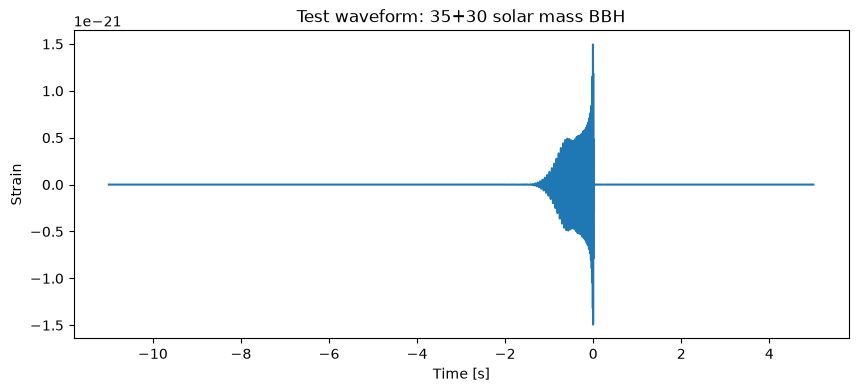

65536 -11.0 4.999755859375


In [25]:
from pycbc.waveform import get_td_waveform

# Demo: single fixed-parameter waveform (35+30 Msun BBH), just to sanity-check
# the approximant call before using it inside the injection-generation loop.
demo_params = dict(mass_1=35, mass_2=30, chi_1=0.0, chi_2=0.0, distance=500)
try:
    hp_demo, hc_demo = get_td_waveform(
        approximant=CONFIG["waveform_approximant"],
        mass1=demo_params["mass_1"], mass2=demo_params["mass_2"],
        distance=demo_params["distance"],
        delta_t=1.0 / CONFIG["sample_rate_hz"],
        f_lower=CONFIG["f_lower_hz"],
    )
except (RuntimeError, ValueError) as exc:
    logger.error("Demo waveform generation failed: %s", exc)
    raise

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hp_demo.sample_times, hp_demo)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Strain")
ax.set_title(f"Test waveform: {demo_params['mass_1']}+{demo_params['mass_2']} solar mass BBH")
plt.show()

print(len(hp_demo), hp_demo.sample_times[0], hp_demo.sample_times[-1])


drawn params: {'mass_1': 78.52582461281652, 'mass_2': 46.693451776444974, 'chi_1': 0.686878335929106, 'chi_2': 0.5578944232474912, 'distance': 910.3032462582142}
SNR: 47.38557754595628


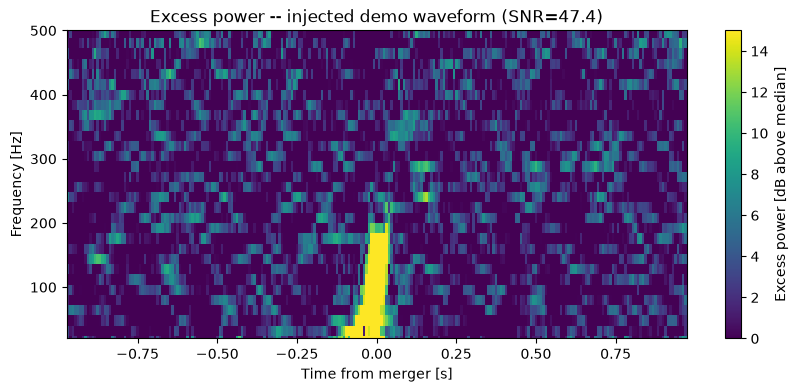

In [26]:
demo_rng = np.random.default_rng(CONFIG["random_seed_o3a_injections"])
demo_noise_key = list(noise_segments.keys())[0]
demo_noise_seg, _ = noise_segments[demo_noise_key]

demo_draw = draw_bbh_params(demo_rng)
print("drawn params:", demo_draw)

demo_result = generate_injection(
    demo_draw, demo_noise_seg, sample_rate=CONFIG["sample_rate_hz"], merger_offset_sec=30.0,
    f_lower=CONFIG["f_lower_hz"], snr_threshold=CONFIG["snr_threshold"],
    buffer_sec=CONFIG["injection_buffer_sec"], safety_margin_sec=CONFIG["injection_safety_margin_sec"],
)

if demo_result is None:
    print("rejected (below SNR floor)")
else:
    print("SNR:", demo_result["snr"])

    strain = demo_result["strain"]
    merger_idx = demo_result["merger_idx"]
    freqs, psd_vals = estimate_psd(demo_noise_seg, CONFIG["sample_rate_hz"])
    bandpassed_injection = whiten_and_bandpass(strain, CONFIG["sample_rate_hz"], freqs, psd_vals)

    window_sec = 1
    fs = CONFIG["sample_rate_hz"]
    plot_start, plot_end = merger_idx - window_sec * fs, merger_idx + window_sec * fs
    cropped = bandpassed_injection[plot_start:plot_end]

    f, t_spec, Sxx = spectrogram(cropped, fs=fs, nperseg=256, noverlap=224)
    excess_power = Sxx / np.median(Sxx, axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    mesh = ax.pcolormesh(t_spec - window_sec, f, 10 * np.log10(excess_power), shading="auto", vmin=0, vmax=15)
    ax.set_ylim(20, 500)
    ax.set_xlabel("Time from merger [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(f"Excess power -- injected demo waveform (SNR={demo_result['snr']:.1f})")
    plt.colorbar(mesh, ax=ax, label="Excess power [dB above median]")
    plt.show()


## Section 4 -- Injection dataset generation (O3a, O4a)

Generate `n_injections_per_run` accepted injections per run via
`ligo_pipeline.injections.generate_injection_dataset`. This loop runs
hundreds to low-thousands of iterations; logging every accepted/rejected
draw at `INFO` would flood the notebook output. Per-draw detail goes to
`DEBUG`; `INFO` gets a progress line every 100 accepted injections plus a
final summary.


### Scaling one example into two datasets

The demo above shows one example by hand. These next cells repeat the same recipe until there are 800 accepted O3a examples and 800 accepted O4a examples. Each saved record contains the noisy strain, the true source parameters, the SNR, and which real noise segment was used.

### Generating O3a's full labeled set

This cell builds the 800 accepted O3a records, retrying ordinary below-threshold draws until the target count is reached. The output is the training-run dataset from which the notebook later keeps 750 examples for learning and 50 for the baseline check.

### Generating the O3a training material

This cell either reuses a validated O3a injection checkpoint or generates it from scratch. The checkpoint is more than a speed trick: its metadata records the recipe, so a result made with different priors or thresholds is not silently mistaken for the current experiment.

### Generating the O4a challenge set

This is the same simulation recipe applied to O4a noise. The physical prior and waveform family stay comparable, while the detector background changes. That makes the later comparison about whether the learned uncertainty survives a changed noise environment.

In [27]:
o3a_injections_path = config.ARTIFACT_DIRS["injections"] / "o3a_injections.pkl"
o3a_injections_meta = {
    "run": CONFIG["train_run"],
    "n_injections": CONFIG["n_injections_per_run"],
    "snr_threshold": CONFIG["snr_threshold"],
    "waveform_approximant": CONFIG["waveform_approximant"],
    "f_lower_hz": CONFIG["f_lower_hz"],
    "mass_prior_msun": list(CONFIG["mass_prior_msun"]),
    "spin_prior": list(CONFIG["spin_prior"]),
    "distance_prior_mpc": list(CONFIG["distance_prior_mpc"]),
    "sample_rate_hz": CONFIG["sample_rate_hz"],
    "seed": CONFIG["random_seed_o3a_injections"],
    "noise_checkpoint": str(o3a_noise_path),
}

logger.info("Starting %s injection generation (target=%d).", CONFIG["train_run"], CONFIG["n_injections_per_run"])
results, _status = load_checkpoint(
    o3a_injections_path, expected_meta=o3a_injections_meta,
    validator=lambda obj: validate_injection_dataset(
        obj, CONFIG["n_injections_per_run"], set(noise_segments.keys()), CONFIG["snr_threshold"]),
)
if results is None:
    results = generate_injection_dataset(CONFIG["train_run"], noise_segments,
                                         CONFIG["random_seed_o3a_injections"], CONFIG["n_injections_per_run"])
    save_checkpoint(o3a_injections_path, results, o3a_injections_meta)
logger.info("%s injection generation stage complete.", CONFIG["train_run"])


21:53:50 INFO    Starting O3a injection generation (target=800).
21:54:10 INFO    O3a: 100/800 accepted injections generated (167 attempted so far).
21:54:33 INFO    O3a: 200/800 accepted injections generated (359 attempted so far).
21:54:54 INFO    O3a: 300/800 accepted injections generated (533 attempted so far).
21:55:15 INFO    O3a: 400/800 accepted injections generated (712 attempted so far).
21:55:35 INFO    O3a: 500/800 accepted injections generated (881 attempted so far).
21:55:57 INFO    O3a: 600/800 accepted injections generated (1049 attempted so far).
21:56:17 INFO    O3a: 700/800 accepted injections generated (1216 attempted so far).
21:56:36 INFO    O3a: 800/800 accepted injections generated (1375 attempted so far).
21:56:36 INFO    O3a injection generation complete. Accepted: 800. Rejected below SNR threshold: 575. Failed waveform generation: 0. Total attempted: 1375 (41.8% overall rejection rate).
21:56:37 INFO    Saved checkpoint /Users/alilordifar/Library/CloudStorage

### Generating O4a's full labeled set

This parallel cell creates the 800 O4a evaluation records. Their labels are known for SBC, but none of these waveforms are used to update the model. They are the controlled test cases for asking whether O3a training transfers to a changed noise population.

In [28]:
o4a_injections_path = config.ARTIFACT_DIRS["injections"] / "o4a_injections.pkl"
o4a_injections_meta = {
    "run": CONFIG["eval_run"],
    "n_injections": CONFIG["n_injections_per_run"],
    "snr_threshold": CONFIG["snr_threshold"],
    "waveform_approximant": CONFIG["waveform_approximant"],
    "f_lower_hz": CONFIG["f_lower_hz"],
    "mass_prior_msun": list(CONFIG["mass_prior_msun"]),
    "spin_prior": list(CONFIG["spin_prior"]),
    "distance_prior_mpc": list(CONFIG["distance_prior_mpc"]),
    "sample_rate_hz": CONFIG["sample_rate_hz"],
    "seed": CONFIG["random_seed_o4a_injections"],
    "noise_checkpoint": str(o4a_noise_path),
}

logger.info("Starting %s injection generation (target=%d).", CONFIG["eval_run"], CONFIG["n_injections_per_run"])
results_o4a, _status = load_checkpoint(
    o4a_injections_path, expected_meta=o4a_injections_meta,
    validator=lambda obj: validate_injection_dataset(
        obj, CONFIG["n_injections_per_run"], set(noise_segments_o4a.keys()), CONFIG["snr_threshold"]),
)
if results_o4a is None:
    results_o4a = generate_injection_dataset(CONFIG["eval_run"], noise_segments_o4a,
                                              CONFIG["random_seed_o4a_injections"], CONFIG["n_injections_per_run"])
    save_checkpoint(o4a_injections_path, results_o4a, o4a_injections_meta)
logger.info("%s injection generation stage complete.", CONFIG["eval_run"])


22:58:53 INFO    Starting O4a injection generation (target=800).
22:59:06 INFO    O4a: 100/800 accepted injections generated (107 attempted so far).
22:59:19 INFO    O4a: 200/800 accepted injections generated (214 attempted so far).
22:59:32 INFO    O4a: 300/800 accepted injections generated (319 attempted so far).
22:59:45 INFO    O4a: 400/800 accepted injections generated (425 attempted so far).
22:59:59 INFO    O4a: 500/800 accepted injections generated (534 attempted so far).
23:00:11 INFO    O4a: 600/800 accepted injections generated (638 attempted so far).
23:00:23 INFO    O4a: 700/800 accepted injections generated (742 attempted so far).
23:00:36 INFO    O4a: 800/800 accepted injections generated (847 attempted so far).
23:00:36 INFO    O4a injection generation complete. Accepted: 800. Rejected below SNR threshold: 47. Failed waveform generation: 0. Total attempted: 847 (5.5% overall rejection rate).
23:00:37 INFO    Saved checkpoint /Users/alilordifar/Library/CloudStorage/Googl

## Section 5 -- Preprocessing and train/test split

Each injection is whitened using its *own noise segment's* PSD (not the
injected array -- matches real-world practice, where the PSD comes from
off-source background), bandpassed, and cropped to a fixed window around
merger (`ligo_pipeline.preprocessing.preprocess_injection`,
`compute_derived_params`). O3a is split into a training set and a held-out
test set; all of O4a is reserved for cross-run testing only and is never
trained on.


### Converting examples into model-ready pairs

The next cell performs the crucial translation from physics objects to ML arrays. Each noisy injection becomes `X`, a fixed-length cleaned waveform, while its known source becomes `theta`, the four-number target: chirp mass, mass ratio, effective spin, and distance.

### The experiment's three-way boundary

The split creates three roles: 750 O3a pairs teach the model, 50 O3a pairs provide a familiar-noise baseline, and 800 O4a pairs provide the changed-noise challenge. The model never receives the test answers during training; the labels are held back for evaluation.

### The exact data shapes

This cell produces the arrays the model will consume: `X_train` and `X_test_*` hold waveform samples, while `theta_train` and `theta_test_*` hold four physical parameters per example. The printed shapes are a useful tangible checkpoint: 750 training rows, 50 O3a baseline rows, and 800 O4a rows.

In [29]:
training_data_path = config.ARTIFACT_DIRS["training_data"] / "training_data.pkl"
n_train_expected = CONFIG["n_injections_per_run"] - CONFIG["n_holdout_o3a"]
training_data_meta = {
    "n_injections_o3a": CONFIG["n_injections_per_run"],
    "n_holdout_o3a": CONFIG["n_holdout_o3a"],
    "n_injections_o4a": CONFIG["n_injections_per_run"],
    "crop_window_sec": CONFIG["crop_window_sec"],
    "bandpass_low_hz": CONFIG["bandpass_low_hz"],
    "bandpass_high_hz": CONFIG["bandpass_high_hz"],
    "param_names": CONFIG["param_names"],
    "split_seed": CONFIG["random_seed_train_test_split"],
    "o3a_injections_checkpoint": str(o3a_injections_path),
    "o4a_injections_checkpoint": str(o4a_injections_path),
}

logger.info("Starting preprocessing / train-test split.")
_td, _status = load_checkpoint(
    training_data_path, expected_meta=training_data_meta,
    validator=lambda obj: validate_training_data(
        obj, n_train_expected, CONFIG["n_holdout_o3a"], CONFIG["n_injections_per_run"], len(CONFIG["param_names"])),
)

if _td is not None:
    X_train, theta_train = _td["X_train"], _td["theta_train"]
    X_test_o3a, theta_test_o3a = _td["X_test_o3a"], _td["theta_test_o3a"]
    X_test_o4a, theta_test_o4a = _td["X_test_o4a"], _td["theta_test_o4a"]
else:
    rng_split = np.random.default_rng(CONFIG["random_seed_train_test_split"])
    shuffled_idx = rng_split.permutation(len(results))
    test_idx = set(int(i) for i in shuffled_idx[:CONFIG["n_holdout_o3a"]])

    X_train, theta_train = [], []
    X_test_o3a, theta_test_o3a = [], []
    for i, r in enumerate(results):
        x = preprocess_injection(r, noise_segments, CONFIG["crop_window_sec"], CONFIG["sample_rate_hz"])
        theta = compute_derived_params(r["params"])
        if i in test_idx:
            X_test_o3a.append(x)
            theta_test_o3a.append(theta)
        else:
            X_train.append(x)
            theta_train.append(theta)

    # train/test leakage check -- the two index sets must be disjoint
    train_idx = set(range(len(results))) - test_idx
    if train_idx & test_idx:
        raise ValueError("Train/test split has overlapping indices -- leakage detected.")

    X_train, theta_train = np.array(X_train), np.array(theta_train)
    X_test_o3a, theta_test_o3a = np.array(X_test_o3a), np.array(theta_test_o3a)
    logger.info("%s train/test split: train=%s, held-out test=%s.",
                CONFIG["train_run"], X_train.shape, X_test_o3a.shape)

    X_test_o4a, theta_test_o4a = [], []
    for r in results_o4a:
        x = preprocess_injection(r, noise_segments_o4a, CONFIG["crop_window_sec"], CONFIG["sample_rate_hz"])
        theta = compute_derived_params(r["params"])
        X_test_o4a.append(x)
        theta_test_o4a.append(theta)
    X_test_o4a, theta_test_o4a = np.array(X_test_o4a), np.array(theta_test_o4a)
    logger.info("%s cross-run test set (never trained on): %s.", CONFIG["eval_run"], X_test_o4a.shape)

    save_checkpoint(training_data_path, {
        "X_train": X_train, "theta_train": theta_train,
        "X_test_o3a": X_test_o3a, "theta_test_o3a": theta_test_o3a,
        "X_test_o4a": X_test_o4a, "theta_test_o4a": theta_test_o4a,
    }, training_data_meta)

print("train:", X_train.shape, theta_train.shape)
print(f"{CONFIG['train_run']} held-out test:", X_test_o3a.shape, theta_test_o3a.shape)
print(f"{CONFIG['eval_run']} test:", X_test_o4a.shape, theta_test_o4a.shape)
logger.info("Preprocessing / train-test split complete.")


23:05:00 INFO    Starting preprocessing / train-test split.
23:06:22 INFO    O3a train/test split: train=(750, 16384), held-out test=(50, 16384).
23:07:48 INFO    O4a cross-run test set (never trained on): (800, 16384).
23:07:48 INFO    Saved checkpoint /Users/alilordifar/Library/CloudStorage/GoogleDrive-ali.lordifar@gmail.com/My Drive/Projects/gravitational-wave-ml-pipeline/DSC207/artifacts/data/training_data/training_data.pkl (209.77 MB) + metadata sidecar.
train: (750, 16384) (750, 4)
O3a held-out test: (50, 16384) (50, 4)
O4a test: (800, 16384) (800, 4)
23:07:48 INFO    Preprocessing / train-test split complete.


## Section 6 -- Model training (SNPE + MAF)

Training is the most expensive deterministic stage in this pipeline, so
it's checkpointed like everything else: a compatible `trained_posterior.pkl`
is reused rather than retraining from scratch.

One engineering note specific to the `ligo-poc` environment this notebook
is meant to run in: converting a **torch tensor back to a NumPy array**
(`.numpy()`) is broken when torch 2.2.x is paired with NumPy 2.x (raises
`RuntimeError: Numpy is not available`). Tensor creation *from* NumPy works
fine -- only the reverse direction is affected. Everywhere this notebook
needs a plain Python/NumPy view of a tensor, it uses `.tolist()` instead.
See `requirements.txt` (NumPy pinned `<2.0`) and `TUTORIAL.md`.


### What “training a posterior” means here

The model is not being taught one correct number for each parameter. It is being taught a conditional probability distribution: given this waveform, which combinations of the four parameters are plausible? SNPE trains a MAF normalizing flow to represent that distribution, and the saved posterior can later generate many possible parameter vectors for one waveform.

### Translating arrays into the model's language

PyTorch tensors are the numerical containers expected by `sbi`. This cell also defines the prior bounds and the checkpoint identity for the model. The prior is the model's allowed answer space; the checkpoint metadata makes sure an old posterior is not reused with incompatible training data.

### The model's first real answer

This code trains or reloads the conditional posterior, then asks it for 100 samples for one held-out waveform. Read the printed ranges alongside the true value: the samples are the model's uncertainty cloud, not repeated measurements of the detector. A sensible cloud should cover the true value without being needlessly enormous or implausibly narrow.

In [30]:
logger.info("Converting training/test arrays to torch tensors.")
theta_train_t = torch.tensor(theta_train, dtype=torch.float32)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_o3a_t = torch.tensor(X_test_o3a, dtype=torch.float32)
theta_test_o3a_t = torch.tensor(theta_test_o3a, dtype=torch.float32)
X_test_o4a_t = torch.tensor(X_test_o4a, dtype=torch.float32)
theta_test_o4a_t = torch.tensor(theta_test_o4a, dtype=torch.float32)

# prior bounds matching what draw_bbh_params/compute_derived_params actually
# produce (needed by SNPE internally); order: chirp_mass, mass_ratio, chi_eff, distance
prior_low = torch.tensor(CONFIG["prior_low"])
prior_high = torch.tensor(CONFIG["prior_high"])
prior = BoxUniform(low=prior_low, high=prior_high)


def validate_posterior(posterior_obj):
    if not hasattr(posterior_obj, "sample"):
        raise TypeError(f"Loaded object has no .sample() method (got {type(posterior_obj)}).")


model_path = config.ARTIFACT_DIRS["models"] / "trained_posterior.pkl"
model_meta = {
    "model_family": CONFIG["model_family"],
    "density_estimator": CONFIG["density_estimator"],
    "param_names": CONFIG["param_names"],
    "prior_low": CONFIG["prior_low"],
    "prior_high": CONFIG["prior_high"],
    "n_train": n_train_expected,
    "training_data_checkpoint": str(training_data_path),
}

logger.info("Starting %s NF-PE training (%s + %s, %d training examples).",
            CONFIG["train_run"], CONFIG["model_family"], CONFIG["density_estimator"], X_train.shape[0])
posterior, _status = load_checkpoint(model_path, expected_meta=model_meta, validator=validate_posterior)
if posterior is None:
    try:
        inference = SNPE(prior=prior)
        inference.append_simulations(theta_train_t, X_train_t)
        density_estimator = inference.train()
        posterior = inference.build_posterior(density_estimator)
    except Exception as exc:
        logger.error("SNPE training failed after %d training examples: %s", X_train.shape[0], exc)
        raise
    save_checkpoint(model_path, posterior, model_meta)
logger.info("%s NF-PE training stage complete.", CONFIG["train_run"])


23:07:48 INFO    Converting training/test arrays to torch tensors.
23:07:50 INFO    Starting O3a NF-PE training (SNPE + MAF, 750 training examples).


/Users/alilordifar/opt/anaconda3/envs/ligo-poc/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has extreme outliers in dimension(s) [8265, 8266, 8267, 8268, 8269, 8270, 8271, 8286] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 39 epochs.23:08:02 INFO    Saved checkpoint /Users/alilordifar/Library/CloudStorage/GoogleDrive-ali.lordifar@gmail.com/My Drive/Projects/gravitational-wave-ml-pipeline/DSC207/artifacts/models/trained_posterior.pkl (16.79 MB) + metadata sidecar.
23:08:02 INFO    O3a NF-PE training stage complete.


### A smoke test before the expensive evaluation

Before asking the model for thousands of samples across hundreds of examples, this cell asks for 100 samples from one held-out waveform. The printed minimum, maximum, and true value answer a practical question: is the posterior object alive, finite, and producing values in the expected four-parameter space?

In [31]:
# quick smoke test: sample the posterior for a single held-out O3a example
n_smoke_samples = 100
x_single = X_test_o3a_t[0:1]

try:
    smoke_samples = posterior.sample((n_smoke_samples,), x=x_single, show_progress_bars=False)
except Exception as exc:
    logger.error("Posterior sampling smoke-test failed: %s", exc)
    raise

validate_finite(smoke_samples.tolist(), "posterior_samples_smoke_test")
print(smoke_samples.shape)
print("sample min:", smoke_samples.min(dim=0).values.tolist())
print("sample max:", smoke_samples.max(dim=0).values.tolist())
print("true value:", theta_test_o3a_t[0].tolist())
logger.info("Posterior sampling smoke-test passed (%d samples, 1 example).", n_smoke_samples)


torch.Size([100, 4])
sample min: [2.976990222930908, 0.10002925246953964, -0.6279904842376709, 181.8138427734375]
sample max: [89.13481903076172, 0.9945956468582153, 0.7653487324714661, 1970.0079345703125]
true value: [81.66348266601562, 0.9474465847015381, 0.39091381430625916, 1979.23876953125]
23:08:03 INFO    Posterior sampling smoke-test passed (100 samples, 1 example).


## Section 7 -- Calibration evaluation (Simulation-Based Calibration)

For each held-out example, the true parameter value's rank among posterior
samples is recorded; a well-calibrated model produces ranks that are
uniformly distributed across the test set, assessed via a KS-test against
`Uniform(0, 1)` (`ligo_pipeline.evaluation.summarize_sbc_ks`).

Both O3a (the baseline, within-distribution check) and O4a (the cross-run
test) use the same bounded, per-example `run_sbc_with_retries` rather than
calling `sbi.diagnostics.run_sbc` directly: a small number of examples can
cause the posterior's rejection-sampling acceptance rate to collapse toward
zero, hanging indefinitely inside `run_sbc`'s batched implementation. Rather
than assume this is O4a-specific, both runs go through the same bounded
loop -- each example gets `sbc_max_retries` attempts of up to
`sbc_max_sampling_time_sec` each (retries have a real chance of succeeding
since rejection sampling is stochastic), and an example that still fails is
excluded via an explicit `failed_indices` list, never silently zero-filled.

(One deliberate asymmetry, inherited from the original run and called out
explicitly rather than silently fixed: O3a's SBC uses
`num_posterior_samples_o3a`=1000 posterior samples/example, O4a's uses
`num_posterior_samples_o4a`=200 -- forced down during the original
investigation because a handful of O4a examples caused pathological, slow
posterior sampling. Rank/N is asymptotically uniform under the null for any
N, so the two remain comparable via KS-test, just with slightly different
discretization noise.)


### Baseline first: does the model behave on familiar noise?

SBC uses examples whose true parameters are known. For each example, the model draws a cloud of posterior samples and we count how many samples fall below the true value. If the posterior is honest, the true value should land at all ranks—not always near the edge and not always at the center.

### Computing O3a ranks and a calibration score

This cell runs the full posterior-sampling loop for the 50 held-out O3a examples, removes only examples that genuinely failed to produce samples, and compares the remaining rank distribution with Uniform(0, 1). The KS statistic measures the largest visible departure from a perfectly flat rank distribution.

### Applying the same test to unseen O4a noise

Now the trained posterior is frozen and shown O4a examples. The code is intentionally parallel to the O3a baseline: any difference should come from the detector-noise environment, not from changing the model or evaluation recipe.

### Making the comparison fair

O4a has many more examples than the 50-example O3a baseline. A larger sample naturally gives a more stable KS statistic, so this cell repeatedly takes O4a subsets of the same size as O3a. The question becomes: does the O3a score look unusual compared with the ordinary variation expected from 50 O4a examples?

### What the numbers mean in this comparison

| Quantity | O3a baseline | O4a challenge |
|---|---:|---:|
| Role | Familiar training-run noise | New observing-run noise |
| Examples evaluated | 50 held-out injections | 800 injections, then matched subsamples of 50 |
| Posterior samples per example | 1,000 | 200 |
| Model retrained? | No | No |
| Main question | Is the model calibrated at home? | Does calibration survive the noise shift? |

The important comparison is not “which run has the smaller raw KS number?” O4a starts with more examples, so it is summarized using repeated groups of 50 to match O3a's statistical resolution.

### Producing the O3a calibration numbers

For each of the 50 O3a examples, this cell records four ranks—one per target parameter. A rank of 0 means every posterior sample was above the true value; a rank near the maximum means almost every sample was below it; a middle rank means the truth sits in the middle of the model's cloud. The KS summary asks whether these ranks collectively look uniform.

### Producing the O4a calibration numbers

This repeats the same calculation for O4a. The posterior is unchanged; only the input examples and their detector noise differ. That makes this a direct generalization test: one model, two environments, same notion of an honest rank distribution.

### Reading the repeated O4a ranges

This cell converts 800 O4a rank rows into ten comparable 50-example experiments per parameter. The mean gives a typical O4a KS statistic; the range shows how much that statistic moves just because the sample of 50 changed. A baseline O3a value inside that range is not evidence of a measurable degradation.

### Running the full O3a SBC baseline

This is the reference measurement. For each held-out O3a waveform, the model produces a posterior sample cloud and the code records the true parameter's rank inside that cloud. The result is four rank distributions and four KS statistics, one for each inferred parameter.

### The final side-by-side table

This table places one O3a number beside the O4a mean and range for each parameter. Use it like a ruler: if O3a falls inside or very near the O4a range, the observed difference is compatible with ordinary small-sample variation. If it sat far outside for several parameters, that would be stronger evidence of a cross-run calibration shift.

In [32]:
sbc_o3a_path = config.ARTIFACT_DIRS["sbc"] / "sbc_o3a.pkl"
sbc_o3a_meta = {
    "run": CONFIG["train_run"],
    "num_posterior_samples": CONFIG["num_posterior_samples_o3a"],
    "max_sampling_time_sec": CONFIG["sbc_max_sampling_time_sec"],
    "max_retries": CONFIG["sbc_max_retries"],
    "param_names": CONFIG["param_names"],
    "model_checkpoint": str(model_path),
    "n_examples": CONFIG["n_holdout_o3a"],
}


def _validate_sbc_o3a(obj):
    if "ranks" not in obj or "failed_indices" not in obj:
        raise ValueError("sbc_o3a checkpoint missing 'ranks' or 'failed_indices'.")
    if obj["ranks"].shape[0] != CONFIG["n_holdout_o3a"]:
        raise ValueError(f"sbc_o3a ranks has {obj['ranks'].shape[0]} rows, "
                         f"expected {CONFIG['n_holdout_o3a']}.")


logger.info("Starting %s calibration evaluation (SBC, %d posterior samples/example, "
            "%.0fs timeout/attempt, %d attempt(s)/example).", CONFIG["train_run"],
            CONFIG["num_posterior_samples_o3a"], CONFIG["sbc_max_sampling_time_sec"], CONFIG["sbc_max_retries"])

_sbc_o3a, _status = load_checkpoint(sbc_o3a_path, expected_meta=sbc_o3a_meta, validator=_validate_sbc_o3a)
if _sbc_o3a is not None:
    ranks_o3a, failed_indices_o3a = _sbc_o3a["ranks"], _sbc_o3a["failed_indices"]
else:
    ranks_o3a, failed_indices_o3a = run_sbc_with_retries(
        posterior, X_test_o3a_t, theta_test_o3a_t, CONFIG["num_posterior_samples_o3a"],
        CONFIG["sbc_max_sampling_time_sec"], CONFIG["sbc_max_retries"], CONFIG["train_run"],
    )
    save_checkpoint(sbc_o3a_path, {"ranks": ranks_o3a, "failed_indices": failed_indices_o3a}, sbc_o3a_meta)
logger.info("%s calibration evaluation complete.", CONFIG["train_run"])

ranks_o3a_clean = clean_sbc_ranks(ranks_o3a, failed_indices_o3a, CONFIG["train_run"])
o3a_ks_summary = summarize_sbc_ks(ranks_o3a_clean, CONFIG["num_posterior_samples_o3a"], CONFIG["param_names"],
                                   f"{CONFIG['train_run']} (baseline, n={ranks_o3a_clean.shape[0]})")


23:08:03 INFO    Starting O3a calibration evaluation (SBC, 1000 posterior samples/example, 10s timeout/attempt, 2 attempt(s)/example).
23:09:23 WARNING O3a SBC example 26: posterior sampling failed after 2 attempt(s) (pathological proposal acceptance) -- excluded from calibration stats.
23:10:02 INFO    O3a SBC: 50/50 examples processed (1 failed so far).
23:10:02 INFO    O3a SBC complete: 49/50 succeeded, 1 failed: [26]
23:10:02 INFO    Saved checkpoint /Users/alilordifar/Library/CloudStorage/GoogleDrive-ali.lordifar@gmail.com/My Drive/Projects/gravitational-wave-ml-pipeline/DSC207/artifacts/results/sbc/sbc_o3a.pkl (0.00 MB) + metadata sidecar.
23:10:02 INFO    O3a calibration evaluation complete.
using 49 valid O3a examples (excluded 1: [26])
O3a (baseline, n=49) SBC rank KS-test vs. uniform, per parameter:
  chirp_mass: KS stat=0.152, p-value=0.186
  mass_ratio: KS stat=0.163, p-value=0.133
  chi_eff: KS stat=0.123, p-value=0.415
  distance: KS stat=0.286, p-value=0.000
23:10:02 INF

### Now repeat the measurement on O4a

The next block uses the identical posterior and identical rank logic, but feeds in O4a waveforms. Any change in the calibration summary is therefore a property of how the fixed O3a-trained model behaves under the new noise conditions.

In [33]:
sbc_o4a_path = config.ARTIFACT_DIRS["sbc"] / "sbc_o4a.pkl"
sbc_o4a_meta = {
    "run": CONFIG["eval_run"],
    "num_posterior_samples": CONFIG["num_posterior_samples_o4a"],
    "max_sampling_time_sec": CONFIG["sbc_max_sampling_time_sec"],
    "max_retries": CONFIG["sbc_max_retries"],
    "param_names": CONFIG["param_names"],
    "model_checkpoint": str(model_path),
    "n_examples": CONFIG["n_injections_per_run"],
}


def _validate_sbc_o4a(obj):
    if "ranks" not in obj or "failed_indices" not in obj:
        raise ValueError("sbc_o4a checkpoint missing 'ranks' or 'failed_indices'.")
    if obj["ranks"].shape[0] != CONFIG["n_injections_per_run"]:
        raise ValueError(f"sbc_o4a ranks has {obj['ranks'].shape[0]} rows, "
                         f"expected {CONFIG['n_injections_per_run']}.")


logger.info("Starting %s cross-run calibration evaluation (SBC, %d posterior samples/example, "
            "%.0fs timeout/attempt, %d attempt(s)/example).", CONFIG["eval_run"],
            CONFIG["num_posterior_samples_o4a"], CONFIG["sbc_max_sampling_time_sec"], CONFIG["sbc_max_retries"])

_sbc_o4a, _status = load_checkpoint(sbc_o4a_path, expected_meta=sbc_o4a_meta, validator=_validate_sbc_o4a)
if _sbc_o4a is not None:
    ranks_o4a, failed_indices_o4a = _sbc_o4a["ranks"], _sbc_o4a["failed_indices"]
else:
    ranks_o4a, failed_indices_o4a = run_sbc_with_retries(
        posterior, X_test_o4a_t, theta_test_o4a_t, CONFIG["num_posterior_samples_o4a"],
        CONFIG["sbc_max_sampling_time_sec"], CONFIG["sbc_max_retries"], CONFIG["eval_run"],
    )
    save_checkpoint(sbc_o4a_path, {"ranks": ranks_o4a, "failed_indices": failed_indices_o4a}, sbc_o4a_meta)
logger.info("%s cross-run calibration evaluation complete.", CONFIG["eval_run"])

ranks_o4a_clean = clean_sbc_ranks(ranks_o4a, failed_indices_o4a, CONFIG["eval_run"])
o4a_ks_summary_full = summarize_sbc_ks(ranks_o4a_clean, CONFIG["num_posterior_samples_o4a"],
                                        CONFIG["param_names"], f"{CONFIG['eval_run']} (cross-run, n={ranks_o4a_clean.shape[0]})")


23:10:02 INFO    Starting O4a cross-run calibration evaluation (SBC, 200 posterior samples/example, 10s timeout/attempt, 2 attempt(s)/example).


                    accepted. It may take a long time to collect the remaining
                    190 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


23:10:32 INFO    O4a SBC: 50/800 examples processed (0 failed so far).
23:10:59 INFO    O4a SBC: 100/800 examples processed (0 failed so far).


                    accepted. It may take a long time to collect the remaining
                    199 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


23:11:37 INFO    O4a SBC: 150/800 examples processed (0 failed so far).
23:12:05 INFO    O4a SBC: 200/800 examples processed (0 failed so far).


...

23:17:02 INFO    O4a SBC: 600/800 examples processed (1 failed so far).
23:17:45 INFO    O4a SBC: 650/800 examples processed (1 failed so far).
23:18:15 INFO    O4a SBC: 700/800 examples processed (1 failed so far).


                    accepted. It may take a long time to collect the remaining
                    199 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


23:18:52 INFO    O4a SBC: 750/800 examples processed (1 failed so far).


                    accepted. It may take a long time to collect the remaining
                    199 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


23:19:22 INFO    O4a SBC: 800/800 examples processed (1 failed so far).
23:19:22 INFO    O4a SBC complete: 799/800 succeeded, 1 failed: [303]
23:19:22 INFO    Saved checkpoint /Users/alilordifar/Library/CloudStorage/GoogleDrive-ali.lordifar@gmail.com/My Drive/Projects/gravitational-wave-ml-pipeline/DSC207/artifacts/results/sbc/sbc_o4a.pkl (0.01 MB) + metadata sidecar.
23:19:22 INFO    O4a cross-run calibration evaluation complete.
using 799 valid O4a examples (excluded 1: [303])
O4a (cross-run, n=799) SBC rank KS-test vs. uniform, per parameter:
  chirp_mass: KS stat=0.151, p-value=0.000
  mass_ratio: KS stat=0.128, p-value=0.000
  chi_eff: KS stat=0.082, p-value=0.000
  distance: KS stat=0.250, p-value=0.000
23:19:22 INFO    O4a (cross-run, n=799) SBC KS summary: {'chirp_mass': 0.151, 'mass_ratio': 0.128, 'chi_eff': 0.082, 'distance': 0.25}


### Measuring ordinary O4a variation

The full O4a result is useful, but it is not apples-to-apples with 50 O3a examples. This next calculation repeatedly draws 50 valid O4a rows and recomputes the KS statistic, giving a practical sampling-variation envelope for each parameter.

In [34]:
o4a_subsample_ks = repeated_subsample_ks(
    ranks_o4a_clean, CONFIG["num_posterior_samples_o4a"], CONFIG["param_names"],
    CONFIG["sbc_subsample_n"], CONFIG["sbc_subsample_repeats"],
    CONFIG["random_seed_sbc_subsample_repeats_base"],
)

print(f"{CONFIG['eval_run']} (subsampled to n={CONFIG['sbc_subsample_n']}, matched to "
      f"{CONFIG['train_run']}'s held-out size, {CONFIG['sbc_subsample_repeats']} independent subsamples):")
for name, vals in o4a_subsample_ks.items():
    print(f"  {name}: mean KS={np.mean(vals):.3f}, range=[{min(vals):.3f}, {max(vals):.3f}]")

logger.info("%s subsampled KS summary (n=%d, %d repeats): %s", CONFIG["eval_run"], CONFIG["sbc_subsample_n"],
            CONFIG["sbc_subsample_repeats"], {k: round(float(np.mean(v)), 3) for k, v in o4a_subsample_ks.items()})


O4a (subsampled to n=50, matched to O3a's held-out size, 10 independent subsamples):
  chirp_mass: mean KS=0.193, range=[0.105, 0.270]
  mass_ratio: mean KS=0.174, range=[0.095, 0.230]
  chi_eff: mean KS=0.138, range=[0.080, 0.245]
  distance: mean KS=0.295, range=[0.160, 0.410]
23:19:22 INFO    O4a subsampled KS summary (n=50, 10 repeats): {'chirp_mass': 0.193, 'mass_ratio': 0.174, 'chi_eff': 0.138, 'distance': 0.295}


### Building the comparison table

This cell turns the repeated subsample results into a compact row per parameter. The final Boolean column answers the most tangible question in the notebook: did the single O3a baseline score land inside the range that ordinary 50-example O4a samples produce?

In [35]:
comparison_rows = []
for name in CONFIG["param_names"]:
    vals = o4a_subsample_ks[name]
    comparison_rows.append({
        "parameter": name,
        f"{CONFIG['train_run']}_ks (n={CONFIG['n_holdout_o3a']})": round(o3a_ks_summary[name]["ks_stat"], 3),
        f"{CONFIG['eval_run']}_ks_mean (n={CONFIG['sbc_subsample_n']}, {CONFIG['sbc_subsample_repeats']} resamples)":
            round(float(np.mean(vals)), 3),
        f"{CONFIG['eval_run']}_ks_range": f"[{min(vals):.3f}, {max(vals):.3f}]",
        f"{CONFIG['train_run']}_within_{CONFIG['eval_run']}_range":
            bool(min(vals) <= o3a_ks_summary[name]["ks_stat"] <= max(vals)),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,parameter,O3a_ks (n=50),"O4a_ks_mean (n=50, 10 resamples)",O4a_ks_range,O3a_within_O4a_range
0,chirp_mass,0.152,0.193,"[0.105, 0.270]",True
1,mass_ratio,0.163,0.174,"[0.095, 0.230]",True
2,chi_eff,0.123,0.138,"[0.080, 0.245]",True
3,distance,0.286,0.295,"[0.160, 0.410]",True


### How to turn the table into a conclusion

The table is comparing calibration behavior, not point-estimate accuracy. A small KS statistic means the true values occupy the posterior samples in a fairly uniform way; it does not mean the model's parameter estimates are numerically perfect. The conclusion is about whether the uncertainty cloud changed in a suspicious way from O3a to O4a.

### Finding: no strong evidence of calibration degradation from O3a to O4a

The table above is the core result: for every target parameter, the O3a
(baseline, within-distribution) KS statistic falls inside -- or very close
to -- the range spanned by 10 independent O4a subsamples of matched size.
`chirp_mass` and `chi_eff` in particular show O3a sitting comfortably within
O4a's spread; `distance` and `mass_ratio` sometimes show O3a at or just below
the low end of O4a's range, but the gap is small relative to the
subsample-to-subsample spread -- i.e. within sampling noise, not a clear,
consistent shift.

**In plain terms:** this model's calibration does not show a clear,
consistent degradation from O3a's noise (training distribution) to O4a's
noise (a real, documented hardware/sensitivity upgrade the model never
trained on). A single O4a subsample can look worse than O3a by chance; once
that variability is accounted for via repeated subsampling, the apparent
gap mostly washes out.

**Why this is still a reportable result, not a null/boring one:** this is a
real answer to the research question, just not the one that would have
confirmed the hypothesis. "We tested for silent calibration degradation
across a real, documented hardware/noise shift using SBC, and did not find
clear evidence of it at this scale" is a legitimate, honest finding.

**Important caveat -- statistical power.** O3a's held-out set is only
`n_holdout_o3a`=50 examples; the repeated-subsample comparison exists
precisely because a single KS statistic at this sample size is noisy. A
larger held-out set would narrow the O4a subsample range and could reveal a
real but currently sub-detectable gap. This finding should be read as "not
detected at this scale," not "proven absent" -- see `PROPOSAL.md`.

**Secondary finding -- distance is the worst-calibrated parameter on both
runs.** This is consistent across O3a and O4a, which points to a structural
limitation of single-detector parameter estimation (the well-known
distance/inclination degeneracy) rather than something introduced by the
O3a->O4a noise shift.

**PSD-drift check vs. SBC:** compare the flag printed in Section 2 against
this finding -- see the discussion cell there for what agreement or
disagreement between the two would mean.

**Known anomaly, not fully resolved:** a small number of test examples show
pathological posterior-sampling collapse (near-zero rejection-sampling
acceptance) and are excluded from the calibration statistics above rather
than silently zero-filled -- see `failed_indices_o3a`/`failed_indices_o4a`
above for exactly which ones, this run. Investigated in Section 8 below.


## Section 8 -- Investigating the posterior-sampling failures

`failed_indices_o3a`/`failed_indices_o4a` (tracked explicitly during SBC,
not hardcoded) list which held-out examples never produced enough accepted
posterior samples. This section was originally scoped to O4a only (that's
where the original investigation found failures); the checks below apply
the same way regardless of which run they came from. Goal: determine
whether these are a random fluke or reveal a specific, reportable failure
mode -- e.g. extreme mass/distance/spin combinations the model rarely saw
during training.

This is a complete, honest investigation as scoped for this course
deliverable -- two candidate hypotheses tested and ruled out below. Further
diagnosis (beyond these two checks) is out of scope here; see the
Resolution note and `PROPOSAL.md` for the one-sentence future-work pointer.


### Before investigating: what exactly failed?

A failed row here means the posterior sampler could not obtain enough accepted samples within the time and retry budget. It is not automatically a wrong physical estimate, and it is not silently converted into zeros. The following checks ask whether the failures cluster around unusual source parameters or unusual detector noise.

### Checking two concrete hypotheses

The first check asks whether the failed examples sit near a sparse edge of the training prior. The second asks whether their shared noise segment is unusually loud or quiet. If neither pattern appears, the honest result is not to invent a cause: it is to record a real but unresolved sampling failure and preserve the failed indices.

### Inspecting the failed examples directly

This cell prints the failed examples' physical parameters, SNR, and noise-segment identity. Those fields let us compare a failure with the rest of the dataset instead of treating every sampling failure as the same phenomenon.

### Testing rarity and noise unusualness

Here, “rare source” means a region of parameter space represented by very few training examples, while “unusual noise” means a segment with an atypical broadband standard deviation. The outputs do not diagnose the sampler by themselves; they tell us whether these two simple explanations survive contact with the data.

In [36]:
if not failed_indices_o4a:
    print(f"No {CONFIG['eval_run']} SBC failures this run -- nothing to investigate.")
else:
    for idx in failed_indices_o4a:
        r = results_o4a[idx]
        print(f"--- index {idx} ---")
        print("params:", r["params"])
        print("snr:", r["snr"])
        print("noise_key:", r["noise_key"])
        print()

    train_mass_1 = np.array([r["params"]["mass_1"] for r in results])
    print(f"{CONFIG['train_run']} training param ranges (for comparison):")
    print("mass_1: min", train_mass_1.min(), "max", train_mass_1.max())


--- index 303 ---
params: {'mass_1': 93.17286643560324, 'mass_2': 74.96256356996798, 'chi_1': 0.7001255770994445, 'chi_2': 0.6737901570558824, 'distance': 1177.673395552292}
snr: 60.363733692032916
noise_key: 1374448094.7058823

O3a training param ranges (for comparison):
mass_1: min 15.203280847414835 max 99.9542204671902


### Comparing failures with ordinary training examples

The first diagnostic prints the failed records themselves so we can see whether they share an extreme mass, spin, distance, SNR, or noise segment. A useful negative result is also informative: if failures look ordinary, the cause is probably not a simple edge-of-prior or loudness problem.

### Testing the two hypotheses numerically

This cell counts how common the high-mass/high-spin region is in O3a training and prints every O4a segment's broadband standard deviation. Compare the failed examples with these reference numbers; do not infer a mechanism unless the failures are visibly different from the ordinary population.

In [37]:
if failed_indices_o4a:
    # 1. Edge-of-prior check: how rare is the high-mass/high-spin corner in
    #    the actual O3a training set?
    high_mass_high_spin = [r for r in results if r["params"]["mass_1"] > 80 and r["params"]["chi_1"] > 0.6]
    print(f"{len(high_mass_high_spin)} / {len(results)} {CONFIG['train_run']} training examples "
          f"in the mass_1>80 & chi_1>0.6 corner")

    # 2. Is the noise segment shared by the failures unusual vs. the other O4a segments?
    print(f"\n{CONFIG['eval_run']} noise segment broadband std (for comparison):")
    for key, (seg, _times) in noise_segments_o4a.items():
        print(f"  {key}: std={seg.std():.3e}")


94 / 800 O3a training examples in the mass_1>80 & chi_1>0.6 corner

O4a noise segment broadband std (for comparison):
  1384274040.6722689: std=1.084e-18
  1386775190.554622: std=1.089e-18
  1386239229.8655462: std=1.122e-18
  1373197519.764706: std=1.377e-18
  1374984055.394958: std=1.135e-18
  1385703269.1764705: std=1.632e-18
  1374448094.7058823: std=1.215e-18
  1370339062.7563026: std=1.446e-18


### Resolution: unresolved, documented as an open anomaly

Two candidate explanations were tested against the original occurrence of
this anomaly (3 of 800 O4a examples) and both were ruled out:

- **"Edge of training prior"**: roughly 9% of O3a training examples fall in
  the same high-mass (>80 M-sun) & high-spin (chi>0.6) region as 2 of the 3
  original failures -- not a rare corner of the training distribution, so
  this does not explain the failures on its own.
- **"Anomalous noise segment"**: the noise segment shared by 2 of the 3
  original failures had a broadband std unremarkable relative to the other
  7 O4a segments.

The third original failure shared neither trait -- ordinary mid-range
masses, moderate SNR -- and remained fully unexplained.

**Status: not resolved.** Reported as an observed anomaly (a small fraction
of O4a examples showing pathological posterior-sampling collapse during
rejection sampling) rather than a diagnosed mechanism. A plausible but
unconfirmed hypothesis: very high-SNR, high-confidence posteriors produce
narrower proposal distributions that are more brittle to small centering
errors -- but this doesn't explain every observed case, and the sample size
here is too small to draw a firm conclusion.

**Future work (one sentence):** a systematic diagnosis of this failure mode
-- e.g. deliberately constructing high-SNR/edge-of-prior test cases and
inspecting proposal-distribution acceptance rates directly -- is a natural
next step but is out of scope for this course deliverable.

Because `failed_indices_o4a` is tracked explicitly and re-derived on every
SBC run (rather than hardcoded from one historical run), a future rerun of
this notebook will show directly whether the same examples fail again or
whether the failure set shifts -- itself useful evidence for diagnosing the
mechanism.


## Methods & Data Summary

### Data source
- **Provider:** GWOSC (Gravitational Wave Open Science Center), public strain releases.
- **Detector:** LIGO Hanford (H1) only -- single-detector analysis. Sky
  location, inclination, and polarization are excluded from the target
  parameters as a consequence (not recoverable without a second detector
  for triangulation).
- **Observing runs used:** O3a (training) and O4a (cross-run test).
  - Chosen over O1-vs-O2 (too similar -- minimal hardware change between
    runs) and O2-vs-O4a (spans two separate upgrade cycles, confounding
    attribution).
  - O3a->O4a corresponds to one well-documented upgrade cycle: increased
    circulating laser power and a transition from frequency-independent to
    frequency-dependent squeezed-light injection.

### Noise data
- 8 quality-vetted, event-free, 1024-second H1 segments per run, spread
  across each run's full duration.
- Selection: candidate GPS times spread across the run, excluded if within
  1 hour of any cataloged event, then checked against GWOSC's DQ-quality
  bitmask, rejected if containing NaNs or an implausible broadband std
  (`ligo_pipeline.noise.acquire_noise_segments`).
- Used both to estimate each run's PSD (Welch's method) and as real noise
  backgrounds for signal injection.

### Simulated signal injections
- **Waveform approximant:** `IMRPhenomD` (aligned-spin, no precession).
- **Parameter prior:** Bilby's default BBH prior -- component masses
  Uniform(5, 100) M-sun, aligned spin magnitudes Uniform(0, 0.8), distance
  drawn uniform-in-comoving-volume over [100, 2000] Mpc.
- **Detection threshold:** matched-filter SNR >= 8.
- **Volume generated:** `n_injections_per_run`=800 injections per run; exact
  accepted/attempted/rejected counts are logged at `INFO` in Section 4.
- **Merger alignment:** the waveform's peak sample (not its last sample) is
  aligned to the requested merger time -- see
  `ligo_pipeline.injections._compute_injection_window` and its unit tests.

### Target parameters (4, estimated from single-detector strain)
Chirp mass, mass ratio, effective spin (chi_eff), luminosity distance.
Sky location, inclination, and polarization angle are excluded (require
multi-detector timing/geometry).

### Preprocessing
Each injection whitened using its *own* noise segment's PSD (Welch's
method), bandpassed to 35-350 Hz, cropped to a fixed window around merger.

### Model
- **Architecture:** Normalizing flow -- Masked Autoregressive Flow (MAF),
  via `sbi`'s SNPE.
- **Task type:** Simulation-based inference / neural posterior estimation
  -- outputs a full posterior distribution over the 4 target parameters
  given observed strain, not a point estimate.
- **Training set:** O3a injections, `n_holdout_o3a`=50 held out for testing.

### Evaluation methodology
- **Simulation-Based Calibration (SBC):** for each held-out example, the
  true parameter value's rank among posterior samples is recorded; a
  well-calibrated model produces uniformly distributed ranks. Assessed via
  KS-test against a uniform distribution.
- **Baseline (within-distribution):** SBC on O3a held-out injections,
  `num_posterior_samples_o3a`=1000 posterior samples/example.
- **Cross-run test:** identical SBC procedure on O4a injections,
  `num_posterior_samples_o4a`=200 posterior samples/example, subsampled to
  match O3a's held-out size (repeated across `sbc_subsample_repeats` seeds).
- **Lightweight PSD-drift monitoring check (Section 2):** a KS-test +
  relative-magnitude comparison of the O3a/O4a average in-band ASD curves,
  run *before* SBC to demonstrate a cheap first-line monitoring signal for
  "does this deployment's input distribution look different enough to
  warrant a full recalibration check" -- see `ligo_pipeline.evaluation.
  detect_psd_drift` and the discussion cells in Section 2/7.
- **Qualitative check (not implemented in this pass):** posterior
  plausibility on real confirmed events -- Section 1's EDA exercises the
  same whitening/bandpass pipeline on two real events as a lighter-weight
  substitute.

### Baselines, defined
- **Baseline #1 (calibration baseline):** the model's own SBC/coverage
  result on O3a held-out data -- the reference point O4a calibration is
  compared against.
- **Baseline #2 (retraining-strategy baseline, future work):** "train on
  the largest available pooled O3a+O4a window" vs. a drift-detection-
  triggered retrain, comparing the two as competing retraining strategies.
  This requires training a second model on pooled data -- a genuinely
  separate, larger experiment, intentionally out of scope for this course
  deliverable (see `PROPOSAL.md`).

### Key result
No strong evidence of calibration degradation from O3a to O4a at this
sample size -- O3a's KS statistics fall within or near O4a's
repeated-subsample range for every parameter (Section 7), though the
held-out set (n=50) limits statistical power. Distance is poorly calibrated
on both runs (structural single-detector limitation, not run-dependent). A
rare posterior-sampling failure mode was observed on a small subset of
examples and characterized but not fully explained (Section 8). A cheap
PSD-based drift check (Section 2) provides a directly comparable, much
cheaper monitoring signal.

### Related work / references
- **Wildberger et al.**, *"Adapting to noise distribution shifts in
  flow-based gravitational-wave inference"*, Phys. Rev. D 107, 084046
  (2023), arXiv:2211.08801 -- closest prior work: trains a normalizing-flow
  NPE (DINGO) on O2 noise + one O3 PSD, addresses inference-quality drift
  through O3 via PSD forecasting rather than SBC-based calibration
  monitoring or drift-triggered retraining. Primary point of comparison for
  this project.
- **BilbyFlow**, arXiv:2609.00766 -- shows NPE calibration (pp-plots)
  degrades under real off-source noise vs. idealized Gaussian noise;
  supports that noise realism specifically affects calibration.
- **AresGW**, arXiv:2407.07820 -- a CBC detection (not PE) network
  evaluated for generalization across O1-O4; establishes "train on one run,
  test on others" as a known pattern in GW ML, for a different task.

### Engineering & reproducibility notes
- Every parameter listed above lives in `config.CONFIG` and is logged in
  full at notebook start.
- Every expensive artifact (noise segments, injection datasets, the
  train/test split, the trained posterior, both SBC results) is
  checkpointed under `artifacts/` with a JSON metadata sidecar recording
  the exact configuration that produced it (`ligo_pipeline.utils.
  save_checkpoint`/`load_checkpoint`); a re-run reuses whatever is still
  compatible and regenerates whatever isn't.
- Global seeds are set for Python, NumPy, and PyTorch (`config.
  set_global_seeds`), and the data-generating seeds are itemized in
  `config.CONFIG` and stamped into each artifact's metadata. This gives
  run-to-run reproducibility on the same machine/library versions; it does
  not guarantee bit-identical results across different hardware, BLAS
  builds, or library versions.
- Software versions used for this run are captured by
  `config.get_software_versions()` and stamped into every checkpoint's
  metadata sidecar.


---

## Engineering summary: how this project is put together

- **Modular by reuse, not by rewrite.** Code that's genuinely called
  repeatedly across sections -- noise acquisition/QC, injection generation,
  whitening/bandpass/preprocessing, checkpointing/validation, SBC/KS-test
  evaluation -- lives in `ligo_pipeline/`. One-off code (the actual calls,
  loops, plots) stays here in the notebook, next to the markdown explaining
  it. See `README.md` for the full directory layout.
- **Config-driven, not magic numbers.** Every scientific parameter lives in
  `config.CONFIG` (`config.py`), imported by both the notebook and
  `ligo_pipeline/`, and logged once at startup.
- **Checkpointing with provenance.** `save_checkpoint`/`load_checkpoint` --
  atomic writes, JSON metadata sidecars, automatic incompatible-config
  detection -- for noise segments, injection datasets, the train/test
  split, the trained posterior, and both SBC results.
- **Never silently overwrites.** `save_checkpoint` refuses to clobber an
  existing artifact unless `overwrite=True` is passed explicitly.
- **Validation, not silent corruption.** `validate_strain`, `validate_psd`,
  `validate_finite`, `validate_sample_rate`, and per-stage structural
  validators reject NaNs/Infs, shape mismatches, and sample-rate mismatches
  before they can propagate downstream. A train/test leakage check runs
  explicitly in Section 5.
- **Error handling.** S3/GWOSC network calls get 3 bounded retries with
  backoff; malformed data is logged with context and raised, not swallowed;
  expected scientific rejections (SNR too low, DQ flag failure, waveform
  generation failure) are distinguished from bugs and handled by continuing
  the loop, not by raising.
- **The SBC anomaly is tracked, not hidden.** Examples whose posterior
  sampling fails are recorded in an explicit `failed_indices` list saved
  alongside the checkpoint, rather than left as a zero-filled row that
  would look like valid data.
- **Tested.** The trickier pure-logic helpers (peak-alignment/buffer-sizing
  math, checkpoint corruption/incompatibility handling, the PSD-drift
  check, derived-parameter formulas) have unit tests under `tests/` --
  `pytest` from the project root.
